# Topic 05 — Investigating Modern Encoder–Decoder Architectures for Image Segmentation

Notebook final assignment — phiên bản hoàn thiện cho Google Colab.

## Mục tiêu

Notebook này khảo sát và so sánh 03 kiến trúc encoder–decoder hiện đại cho image segmentation:

1. **U-Net**
2. **SegNet**
3. **DeepLabV3+ Compact**

Notebook được thiết kế theo hướng **controlled experiments**, có thể chạy trên Google Colab Free với T4 GPU.

## Dataset

Notebook hỗ trợ 02 dataset thật thuộc 02 domain khác nhau:

- **Oxford-IIIT Pet**: domain ảnh tự nhiên.
- **Kvasir-SEG**: domain ảnh y sinh, phân đoạn polyp nội soi.

Kvasir-SEG được chuẩn bị tự động từ file:

```text
kvasir-seg.zip
```

nếu file này nằm trong Google Drive hoặc thư mục Colab.

## Output

Kết quả được chia riêng theo từng dataset:

```text
outputs_topic05/
    OxfordPet/
        all_results.csv
        summary_mean_std.csv
        history/
        checkpoints/
        figures/

    KvasirSEG/
        all_results.csv
        summary_mean_std.csv
        history/
        checkpoints/
        figures/

    combined_summary_mean_std.csv
```

# 1. Research Questions và Hypotheses

## Research Questions

**RQ1.** Trong ba kiến trúc encoder–decoder, mô hình nào đạt hiệu năng segmentation tốt nhất theo Mean IoU và Dice?

**RQ2.** Khi thay đổi lượng dữ liệu huấn luyện, mô hình nào ổn định hơn?

**RQ3.** Khi thay đổi learning rate, mô hình nào hội tụ ổn định hơn?

**RQ4.** Mô hình nào có trade-off tốt nhất giữa accuracy, latency và memory footprint?

**RQ5.** Hiệu năng của các mô hình thay đổi như thế nào giữa natural image segmentation và medical image segmentation?

## Hypotheses

**H1.** U-Net có hiệu năng tốt nhờ skip connections giúp phục hồi chi tiết không gian.

**H2.** SegNet có chi phí tính toán hợp lý nhưng có thể kém hơn ở vùng biên phức tạp.

**H3.** DeepLabV3+ Compact có lợi thế trong việc khai thác ngữ cảnh đa tỉ lệ nhờ ASPP.

**H4.** Khi giảm training data, mô hình có decoder mạnh và skip/multi-scale features sẽ suy giảm ít hơn.

**H5.** Không có mô hình tối ưu tuyệt đối; lựa chọn phụ thuộc vào trade-off accuracy–latency–memory và domain dữ liệu.

# 2. Controlled Experimental Design

Để đảm bảo công bằng:

| Thành phần | Thiết kế |
|---|---|
| Data split | Cố định theo seed |
| Input size | Giống nhau giữa các mô hình |
| Optimizer | AdamW |
| Loss | CrossEntropy + Dice Loss |
| Metrics | Pixel Accuracy, Mean IoU, Mean Dice, Per-class IoU, Per-class Dice |
| Inference condition | Cùng input size, cùng batch inference |
| Reliability | Multiple seeds |
| Data scarcity | Multiple data fractions |
| Hyperparameter | Multiple learning rates |
| Output | Tách riêng theo từng dataset |

`QUICK_RUN=True` chỉ dùng để kiểm tra pipeline.  
Khi chạy kết quả cuối, đặt `QUICK_RUN=False` và dùng T4 GPU.

In [1]:
# ============================================================
# 3. Imports
# ============================================================

import os
import json
import time
import random
import shutil
import zipfile
import warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, random_split

import torchvision
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from tqdm.auto import tqdm

try:
    from torchinfo import summary as torchinfo_summary
    HAS_TORCHINFO = True
except Exception:
    HAS_TORCHINFO = False

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("MPS available:", hasattr(torch.backends, "mps") and torch.backends.mps.is_available())
print("In Colab:", IN_COLAB)

Torch: 2.11.0+cpu
Torchvision: 0.26.0+cpu
CUDA available: False
MPS available: False
In Colab: True


In [2]:
# ============================================================
# 4. Config
# ============================================================

@dataclass
class Config:
    PROJECT_NAME: str = "Topic05_EncoderDecoder_Segmentation"
    DATA_ROOT: str = "/content/datasets"
    OUTPUT_ROOT: str = "/content/outputs_topic05"

    IMG_SIZE: int = 128
    BATCH_SIZE: int = 8
    NUM_WORKERS: int = 2

    QUICK_RUN: bool = True
    ALLOW_DOWNLOAD: bool = True

    QUICK_EPOCHS: int = 1
    FINAL_EPOCHS: int = 15

    MODELS: Tuple[str, ...] = ("unet", "segnet", "deeplabv3plus")
    SEEDS: Tuple[int, ...] = (42, 2025, 3407)
    DATA_FRACTIONS: Tuple[float, ...] = (1.0, 0.5, 0.25)
    LEARNING_RATES: Tuple[float, ...] = (1e-3, 3e-4)

    # Nếu QUICK_RUN=True, vẫn chạy tất cả dataset thật khả dụng để kiểm tra 2 domain
    QUICK_RUN_ALL_DATASETS: bool = True

    KVASIR_ZIP_NAME: str = "kvasir-seg.zip"
    AUTO_DOWNLOAD_KVASIR: bool = False  # Khuyến nghị: dùng file zip local để tránh lỗi SSL
    KVASIR_URLS: Tuple[str, ...] = (
        "https://datasets.simula.no/downloads/kvasir-seg.zip",
        "https://datasets.simula.no/kvasir-seg/kvasir-seg.zip",
    )
    KVASIR_IMAGE_DIR: str = "/content/datasets/kvasir_seg/images"
    KVASIR_MASK_DIR: str = "/content/datasets/kvasir_seg/masks"

cfg = Config()

Path(cfg.DATA_ROOT).mkdir(parents=True, exist_ok=True)
Path(cfg.OUTPUT_ROOT).mkdir(parents=True, exist_ok=True)

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = get_device()
print("Device:", device)

with open(Path(cfg.OUTPUT_ROOT) / "config.json", "w", encoding="utf-8") as f:
    json.dump(cfg.__dict__, f, indent=2, ensure_ascii=False)

Device: cpu


# 3. Dataset Policy

Notebook sử dụng **real datasets** làm kết quả chính.

- `OxfordPet`: dataset chính, domain ảnh tự nhiên.
- `KvasirSEG`: dataset domain ảnh y sinh, được dùng khi đã chuẩn bị folder đã giải nén trên Google Drive.
- Không sử dụng synthetic dataset làm kết quả chính.
- Nếu Kvasir-SEG chưa có, notebook sẽ skip dataset này và vẫn chạy OxfordPet để kiểm tra pipeline.

## Cấu trúc Kvasir-SEG cần chuẩn bị

Trong Google Drive, đặt folder đã giải nén cạnh notebook:

```text
MyDrive/
  Colab Notebooks/
    Topic05_EncoderDecoder_Segmentation_Colab_9plus_KvasirReady_v4.ipynb
    Kvasir-SEG/
      images/
        xxx.jpg
      masks/
        xxx.png
      kvasir_bboxes.json
```

Notebook sẽ tự copy dữ liệu về:

```text
/content/datasets/kvasir_seg/images
/content/datasets/kvasir_seg/masks
```

để training nhanh và ổn định hơn.


## 3.1. Chuẩn bị Kvasir-SEG tự động

Notebook này ưu tiên dùng `kvasir-seg.zip` nếu người dùng đặt file trong Drive. Nếu không tìm thấy file zip local và `cfg.AUTO_DOWNLOAD_KVASIR=True`, notebook sẽ thử tải Kvasir-SEG từ URL chính thức. Sau đó notebook chuẩn hóa cấu trúc về:

```text
/content/datasets/kvasir_seg/images
/content/datasets/kvasir_seg/masks
```

Nếu Kvasir-SEG vẫn không khả dụng do lỗi mạng hoặc thiếu file, notebook sẽ in cảnh báo rõ ràng và vẫn chạy với OxfordPet để kiểm tra pipeline. Khi nộp bài target 9+, cần đảm bảo `available_datasets` có cả:

```python
['OxfordPet', 'KvasirSEG']
```


In [3]:
# ============================================================
# 5. Mount Drive và chuẩn bị Kvasir-SEG từ folder đã giải nén
# ============================================================
# Trường hợp sử dụng:
#   Bạn đã giải nén Kvasir-SEG và upload folder vào Google Drive:
#
#   /content/drive/MyDrive/Colab Notebooks/Kvasir-SEG/
#       images/
#       masks/
#       kvasir_bboxes.json
#
# Cell này KHÔNG tải Kvasir-SEG qua URL và KHÔNG yêu cầu file zip.
# Mục tiêu là copy dữ liệu từ Google Drive về /content/datasets để training nhanh hơn.

from pathlib import Path
import os
import shutil
import warnings

IMAGE_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]

def count_image_files(folder):
    folder = Path(folder)
    if not folder.exists():
        return 0
    return len([
        p for p in folder.glob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    ])

def mount_drive_if_colab(force_remount=False):
    """
    Mount Google Drive an toàn.
    Nếu Drive mount lỗi, hãy dùng:
        Runtime -> Restart session
    rồi chạy lại cell này và cấp quyền Drive.
    """
    if not IN_COLAB:
        print("[Drive] Không chạy trên Colab.")
        return False

    drive_root = Path("/content/drive/MyDrive")

    if drive_root.exists():
        try:
            # Nếu Drive đã mount và có thể đọc thư mục
            _ = list(drive_root.iterdir())
            print("[Drive] Đã được mount:", drive_root)
            return True
        except Exception:
            pass

    try:
        drive.mount("/content/drive", force_remount=force_remount)
        if drive_root.exists():
            print("[Drive] Mounted:", drive_root)
            return True
    except Exception as e:
        print("[Drive] Mount failed:", repr(e))
        print("Hướng xử lý: Runtime → Restart session, sau đó chạy lại cell này và cấp quyền Google Drive.")
        return False

    return False

def get_kvasir_candidate_roots():
    """
    Các vị trí thường gặp của folder Kvasir-SEG đã giải nén.
    Ưu tiên folder cùng thư mục với notebook trong Google Drive.
    """
    return [
        Path("/content/drive/MyDrive/Colab Notebooks/Kvasir-SEG"),
        Path("/content/drive/MyDrive/Kvasir-SEG"),
        Path("/content/drive/MyDrive/datasets/Kvasir-SEG"),
        Path("/content/drive/MyDrive/datasets/kvasir_seg"),
        Path("/content/Kvasir-SEG"),
        Path("/content/datasets/Kvasir-SEG"),
        Path("./Kvasir-SEG"),
    ]

def find_extracted_kvasir_folder():
    """
    Tìm folder Kvasir-SEG đã giải nén.
    Folder hợp lệ phải có:
        images/
        masks/
    và mỗi folder có ít nhất 1 file ảnh.
    """
    candidate_roots = get_kvasir_candidate_roots()

    for root in candidate_roots:
        img_dir = root / "images"
        mask_dir = root / "masks"

        n_img = count_image_files(img_dir)
        n_mask = count_image_files(mask_dir)

        if img_dir.exists() and mask_dir.exists() and n_img > 0 and n_mask > 0:
            print("[KvasirSEG] Found extracted dataset:", root)
            print("[KvasirSEG] Images:", n_img)
            print("[KvasirSEG] Masks :", n_mask)
            return root

    # Nếu chưa thấy ở các vị trí mặc định, tìm đệ quy trong Colab Notebooks
    search_roots = [
        Path("/content/drive/MyDrive/Colab Notebooks"),
        Path("/content/drive/MyDrive"),
    ]

    for search_root in search_roots:
        if not search_root.exists():
            continue

        print("[KvasirSEG] Đang tìm folder Kvasir-SEG trong:", search_root)

        for root in search_root.rglob("*"):
            if not root.is_dir():
                continue

            if root.name.lower() in ["kvasir-seg", "kvasir_seg"]:
                img_dir = root / "images"
                mask_dir = root / "masks"

                n_img = count_image_files(img_dir)
                n_mask = count_image_files(mask_dir)

                if img_dir.exists() and mask_dir.exists() and n_img > 0 and n_mask > 0:
                    print("[KvasirSEG] Found by recursive search:", root)
                    print("[KvasirSEG] Images:", n_img)
                    print("[KvasirSEG] Masks :", n_mask)
                    return root

    print("[KvasirSEG] Không tìm thấy folder Kvasir-SEG đã giải nén.")
    print("Cấu trúc mong muốn:")
    print("/content/drive/MyDrive/Colab Notebooks/Kvasir-SEG/images")
    print("/content/drive/MyDrive/Colab Notebooks/Kvasir-SEG/masks")
    return None

def prepare_kvasir_from_extracted_folder(cfg: Config, force=False):
    """
    Chuẩn hóa Kvasir-SEG từ folder đã giải nén trên Drive về:
        /content/datasets/kvasir_seg/images
        /content/datasets/kvasir_seg/masks

    Lý do copy về /content:
    - Đọc ảnh từ /content nhanh hơn đọc trực tiếp từ Google Drive.
    - Training ổn định hơn trên Colab.
    """
    final_img_dir = Path(cfg.KVASIR_IMAGE_DIR)
    final_mask_dir = Path(cfg.KVASIR_MASK_DIR)

    # Nếu đã chuẩn bị trong /content rồi thì dùng lại
    n_img = count_image_files(final_img_dir)
    n_mask = count_image_files(final_mask_dir)

    if n_img > 0 and n_mask > 0 and not force:
        print(f"[KvasirSEG] Ready in /content: {n_img} images, {n_mask} masks")
        return True

    # Mount Drive
    drive_ok = mount_drive_if_colab(force_remount=False)

    # Tìm folder đã giải nén
    extracted_root = find_extracted_kvasir_folder()

    if extracted_root is None:
        print("[KvasirSEG] Không có dữ liệu. KvasirSEG sẽ bị skip.")
        print("Hãy upload folder Kvasir-SEG đã giải nén vào:")
        print("/content/drive/MyDrive/Colab Notebooks/Kvasir-SEG/")
        return False

    src_img_dir = extracted_root / "images"
    src_mask_dir = extracted_root / "masks"

    if force:
        if final_img_dir.exists():
            shutil.rmtree(final_img_dir)
        if final_mask_dir.exists():
            shutil.rmtree(final_mask_dir)

    final_img_dir.mkdir(parents=True, exist_ok=True)
    final_mask_dir.mkdir(parents=True, exist_ok=True)

    print("[KvasirSEG] Copying images to:", final_img_dir)
    shutil.copytree(src_img_dir, final_img_dir, dirs_exist_ok=True)

    print("[KvasirSEG] Copying masks to:", final_mask_dir)
    shutil.copytree(src_mask_dir, final_mask_dir, dirs_exist_ok=True)

    n_img = count_image_files(final_img_dir)
    n_mask = count_image_files(final_mask_dir)

    print(f"[KvasirSEG] Prepared: {n_img} images, {n_mask} masks")

    if n_img == 0 or n_mask == 0:
        print("[KvasirSEG] Chuẩn hóa thất bại vì images/masks rỗng.")
        return False

    if n_img != n_mask:
        warnings.warn(
            f"Số ảnh ({n_img}) và số mask ({n_mask}) không bằng nhau. "
            "Dataset loader sẽ ghép theo thứ tự sorted và dùng số lượng nhỏ hơn."
        )

    return True

def inspect_kvasir_folders(cfg: Config):
    print("Kvasir image dir:", cfg.KVASIR_IMAGE_DIR, Path(cfg.KVASIR_IMAGE_DIR).exists(), count_image_files(cfg.KVASIR_IMAGE_DIR))
    print("Kvasir mask dir :", cfg.KVASIR_MASK_DIR, Path(cfg.KVASIR_MASK_DIR).exists(), count_image_files(cfg.KVASIR_MASK_DIR))

kvasir_ready = prepare_kvasir_from_extracted_folder(cfg, force=False)
inspect_kvasir_folders(cfg)

Mounted at /content/drive
[Drive] Mounted: /content/drive/MyDrive
[KvasirSEG] Found extracted dataset: /content/drive/MyDrive/Colab Notebooks/Kvasir-SEG
[KvasirSEG] Images: 1000
[KvasirSEG] Masks : 1000
[KvasirSEG] Copying images to: /content/datasets/kvasir_seg/images
[KvasirSEG] Copying masks to: /content/datasets/kvasir_seg/masks
[KvasirSEG] Prepared: 1000 images, 1000 masks
Kvasir image dir: /content/datasets/kvasir_seg/images True 1000
Kvasir mask dir : /content/datasets/kvasir_seg/masks True 1000


In [8]:
# ============================================================
# 6. Dataset classes
# ============================================================

class OxfordPetSegDataset(Dataset):
    def __init__(self, root: str, split: str, image_size: int, download: bool):
        self.dataset = OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=download
        )
        self.image_tf = transforms.Compose([
            transforms.Resize((image_size, image_size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])
        ])
        self.mask_resize = transforms.Resize(
            (image_size, image_size),
            interpolation=transforms.InterpolationMode.NEAREST
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, mask = self.dataset[idx]
        img = img.convert("RGB")
        img = self.image_tf(img)

        mask = self.mask_resize(mask)
        mask_np = np.array(mask).astype(np.int64)

        # Oxford trimap: 1 pet, 2 background, 3 boundary
        mapped = np.zeros_like(mask_np, dtype=np.int64)
        mapped[mask_np == 2] = 0
        mapped[mask_np == 1] = 1
        mapped[mask_np == 3] = 2

        return img, torch.from_numpy(mapped).long()


class FolderBinarySegDataset(Dataset):
    def __init__(self, image_dir: str, mask_dir: str, image_size: int):
        self.image_paths = sorted([
            p for p in Path(image_dir).glob("*")
            if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
        ])
        self.mask_paths = sorted([
            p for p in Path(mask_dir).glob("*")
            if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
        ])

        if len(self.image_paths) == 0 or len(self.mask_paths) == 0:
            raise RuntimeError("Folder dataset rỗng.")
        if len(self.image_paths) != len(self.mask_paths):
            warnings.warn(f"Số ảnh ({len(self.image_paths)}) và mask ({len(self.mask_paths)}) không bằng nhau. Sẽ ghép theo thứ tự sorted.")

        n = min(len(self.image_paths), len(self.mask_paths))
        self.image_paths = self.image_paths[:n]
        self.mask_paths = self.mask_paths[:n]

        self.image_tf = transforms.Compose([
            transforms.Resize((image_size, image_size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])
        ])
        self.mask_resize = transforms.Resize(
            (image_size, image_size),
            interpolation=transforms.InterpolationMode.NEAREST
        )

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")

        img = self.image_tf(img)
        mask = self.mask_resize(mask)
        mask_np = np.array(mask)
        mask_np = (mask_np > 127).astype(np.int64)

        return img, torch.from_numpy(mask_np).long()

In [7]:
# ============================================================
# 7. Build dataset and output folders
# ============================================================

def split_dataset(dataset, seed: int, train_ratio=0.70, val_ratio=0.15):
    n = len(dataset)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    n_test = n - n_train - n_val
    generator = torch.Generator().manual_seed(seed)
    return random_split(dataset, [n_train, n_val, n_test], generator=generator)

def build_dataset(name: str, seed: int, cfg: Config):
    if name == "OxfordPet":
        trainval = OxfordPetSegDataset(
            root=cfg.DATA_ROOT,
            split="trainval",
            image_size=cfg.IMG_SIZE,
            download=cfg.ALLOW_DOWNLOAD
        )
        train_ds, val_ds, _ = split_dataset(trainval, seed=seed)
        test_ds = OxfordPetSegDataset(
            root=cfg.DATA_ROOT,
            split="test",
            image_size=cfg.IMG_SIZE,
            download=cfg.ALLOW_DOWNLOAD
        )
        return {
            "name": "OxfordPet",
            "train": train_ds,
            "val": val_ds,
            "test": test_ds,
            "num_classes": 3,
            "class_names": ["background", "pet", "boundary"],
        }

    if name == "KvasirSEG":
        if not (Path(cfg.KVASIR_IMAGE_DIR).exists() and Path(cfg.KVASIR_MASK_DIR).exists()):
            raise RuntimeError("KvasirSEG chưa khả dụng.")
        full = FolderBinarySegDataset(cfg.KVASIR_IMAGE_DIR, cfg.KVASIR_MASK_DIR, cfg.IMG_SIZE)
        train_ds, val_ds, test_ds = split_dataset(full, seed=seed)
        return {
            "name": "KvasirSEG",
            "train": train_ds,
            "val": val_ds,
            "test": test_ds,
            "num_classes": 2,
            "class_names": ["background", "polyp"],
        }

    raise ValueError(name)

def get_available_datasets(cfg: Config):
    available = []
    for name in ["OxfordPet", "KvasirSEG"]:
        try:
            _ = build_dataset(name, seed=42, cfg=cfg)
            available.append(name)
        except Exception as e:
            print(f"[Dataset] Skip {name}: {e}")
    if len(available) == 0:
        raise RuntimeError("Không có dataset thật nào khả dụng.")
    print("Available datasets:", available)
    return available

def make_dataset_output_dirs(cfg: Config, dataset_name: str):
    base = Path(cfg.OUTPUT_ROOT) / dataset_name
    dirs = {
        "base": base,
        "history": base / "history",
        "checkpoints": base / "checkpoints",
        "figures": base / "figures",
    }
    for d in dirs.values():
        d.mkdir(parents=True, exist_ok=True)
    return dirs

# Đảm bảo Kvasir-SEG được chuẩn bị ngay trước khi kiểm tra dataset khả dụng.
prepare_kvasir_from_extracted_folder(cfg, force=False)
available_datasets = get_available_datasets(cfg)

[KvasirSEG] Ready in /content: 1000 images, 1000 masks
Available datasets: ['OxfordPet', 'KvasirSEG']


In [9]:
# ============================================================
# 7b. Diagnostic: xác nhận cả OxfordPet và KvasirSEG
# ============================================================

available_datasets = get_available_datasets(cfg)
print("Available datasets:", available_datasets)

assert "OxfordPet" in available_datasets, "OxfordPet chưa khả dụng."

if "KvasirSEG" not in available_datasets:
    print("[CẢNH BÁO] KvasirSEG chưa khả dụng.")
    print("Kiểm tra lại: file kvasir-seg.zip phải nằm ở /content/drive/MyDrive/Colab Notebooks/kvasir-seg.zip")
else:
    print("[OK] KvasirSEG đã khả dụng. Notebook sẽ chạy cả 2 domain.")

inspect_kvasir_folders(cfg)

Available datasets: ['OxfordPet', 'KvasirSEG']
Available datasets: ['OxfordPet', 'KvasirSEG']
[OK] KvasirSEG đã khả dụng. Notebook sẽ chạy cả 2 domain.
Kvasir image dir: /content/datasets/kvasir_seg/images True 1000
Kvasir mask dir : /content/datasets/kvasir_seg/masks True 1000


Available datasets: ['OxfordPet', 'KvasirSEG']
Available datasets for visualization: ['OxfordPet', 'KvasirSEG']

VISUALIZE DATASET: OxfordPet
Dataset: OxfordPet
Num classes: 3
Class names: ['background', 'pet', 'boundary']
Train size: 2576
Val size: 552
Test size: 3669


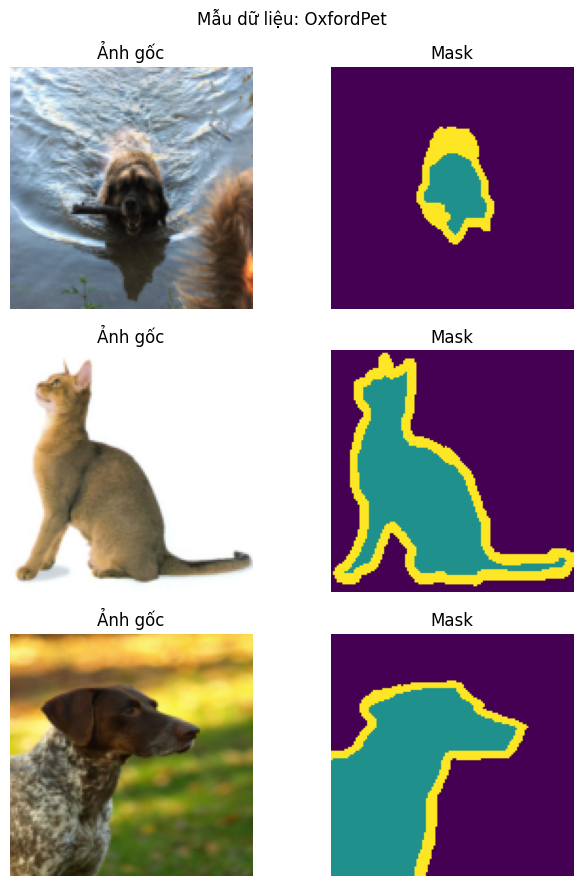

Class distribution OxfordPet:   0%|          | 0/100 [00:00<?, ?it/s]

,class,pixel_count,ratio
0,background,924645,0.564359
1,pet,521221,0.318128
2,boundary,192534,0.117513


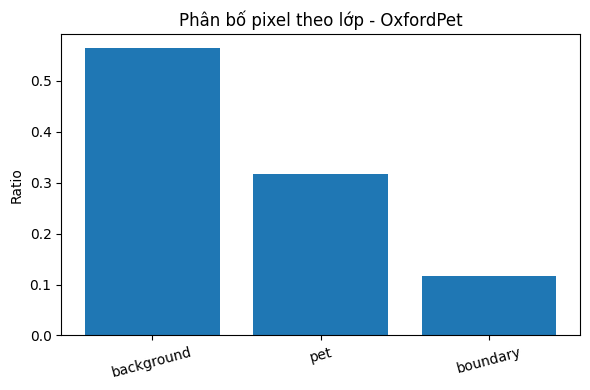


VISUALIZE DATASET: KvasirSEG
Dataset: KvasirSEG
Num classes: 2
Class names: ['background', 'polyp']
Train size: 700
Val size: 150
Test size: 150


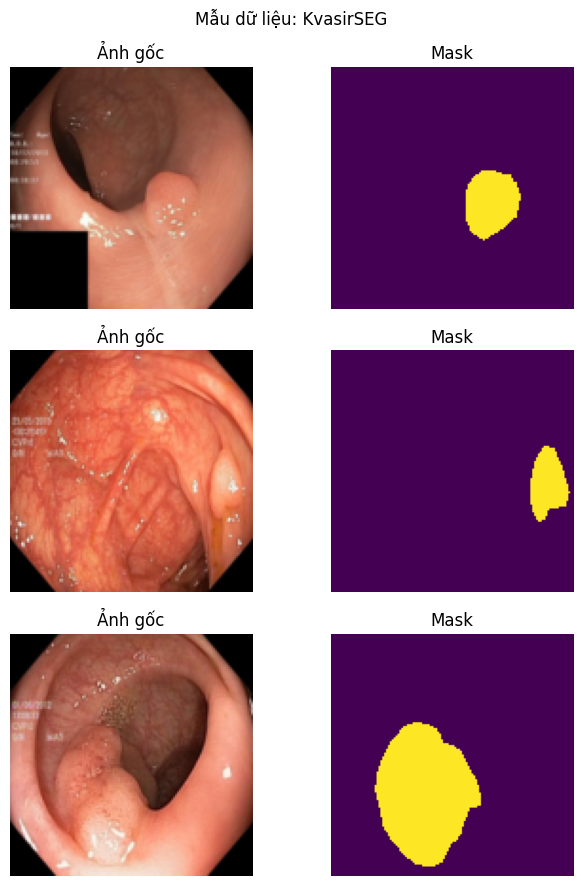

Class distribution KvasirSEG:   0%|          | 0/100 [00:00<?, ?it/s]

,class,pixel_count,ratio
0,background,1365138,0.833214
1,polyp,273262,0.166786


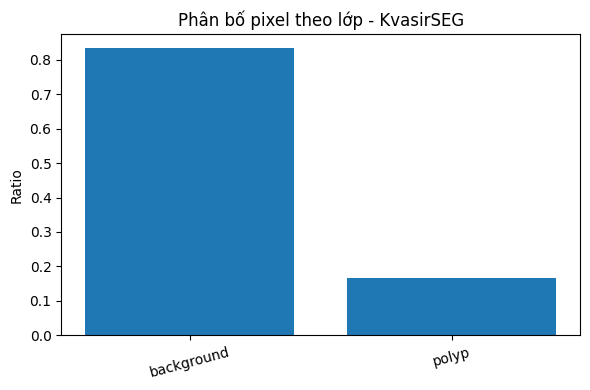

In [10]:

# ============================================================
# 8. Dataset visualization — kiểm tra và hiển thị từng dataset khả dụng
# ============================================================

def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return torch.clamp(img_tensor.cpu() * std + mean, 0, 1)

def show_dataset_samples(dataset_pack, n=4):
    ds = dataset_pack["train"]
    class_names = dataset_pack["class_names"]
    n = min(n, len(ds))
    fig, axes = plt.subplots(n, 2, figsize=(7, 3*n))
    if n == 1:
        axes = np.expand_dims(axes, 0)
    for i in range(n):
        img, mask = ds[i]
        axes[i,0].imshow(denormalize(img).permute(1,2,0))
        axes[i,0].set_title("Ảnh gốc")
        axes[i,0].axis("off")
        axes[i,1].imshow(mask, vmin=0, vmax=len(class_names)-1)
        axes[i,1].set_title("Mask")
        axes[i,1].axis("off")
    plt.suptitle(f"Mẫu dữ liệu: {dataset_pack['name']}")
    plt.tight_layout()
    plt.show()

def plot_class_distribution(dataset_pack, max_samples=200):
    ds = dataset_pack["train"]
    num_classes = dataset_pack["num_classes"]
    class_names = dataset_pack["class_names"]
    counts = np.zeros(num_classes, dtype=np.int64)
    n = min(len(ds), max_samples)
    for i in tqdm(range(n), desc=f"Class distribution {dataset_pack['name']}"):
        _, mask = ds[i]
        for c in range(num_classes):
            counts[c] += int((mask == c).sum())
    df = pd.DataFrame({"class": class_names, "pixel_count": counts, "ratio": counts / counts.sum()})
    display(df)
    plt.figure(figsize=(6,4))
    plt.bar(df["class"], df["ratio"])
    plt.title(f"Phân bố pixel theo lớp - {dataset_pack['name']}")
    plt.ylabel("Ratio")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

# Cập nhật lại danh sách dataset sau khi Kvasir-SEG đã được chuẩn bị.
available_datasets = get_available_datasets(cfg)
print("Available datasets for visualization:", available_datasets)

for ds_name in available_datasets:
    print("\n" + "="*80)
    print(f"VISUALIZE DATASET: {ds_name}")
    print("="*80)
    try:
        pack = build_dataset(ds_name, seed=42, cfg=cfg)
        print("Dataset:", pack["name"])
        print("Num classes:", pack["num_classes"])
        print("Class names:", pack["class_names"])
        print("Train size:", len(pack["train"]))
        print("Val size:", len(pack["val"]))
        print("Test size:", len(pack["test"]))

        show_dataset_samples(pack, n=3)
        plot_class_distribution(pack, max_samples=100)
    except Exception as e:
        print(f"[ERROR] Không visualize được dataset {ds_name}: {e}")


# 4. Model Architectures

Notebook triển khai 03 mô hình:

- U-Net
- SegNet
- DeepLabV3+ Compact

Các mô hình đều trả về logits có shape:

```text
[B, num_classes, H, W]
```

In [11]:
# ============================================================
# 9. Models
# ============================================================

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self, num_classes, base=32):
        super().__init__()
        self.e1 = DoubleConv(3, base)
        self.e2 = DoubleConv(base, base*2)
        self.e3 = DoubleConv(base*2, base*4)
        self.pool = nn.MaxPool2d(2)
        self.b = DoubleConv(base*4, base*8)
        self.u3 = nn.ConvTranspose2d(base*8, base*4, 2, 2)
        self.d3 = DoubleConv(base*8, base*4)
        self.u2 = nn.ConvTranspose2d(base*4, base*2, 2, 2)
        self.d2 = DoubleConv(base*4, base*2)
        self.u1 = nn.ConvTranspose2d(base*2, base, 2, 2)
        self.d1 = DoubleConv(base*2, base)
        self.out = nn.Conv2d(base, num_classes, 1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        b = self.b(self.pool(e3))
        d3 = self.d3(torch.cat([self.u3(b), e3], dim=1))
        d2 = self.d2(torch.cat([self.u2(d3), e2], dim=1))
        d1 = self.d1(torch.cat([self.u1(d2), e1], dim=1))
        return self.out(d1)

class SegNet(nn.Module):
    def __init__(self, num_classes, base=32):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(3, base, 3, padding=1), nn.BatchNorm2d(base), nn.ReLU(inplace=True))
        self.enc2 = nn.Sequential(nn.Conv2d(base, base*2, 3, padding=1), nn.BatchNorm2d(base*2), nn.ReLU(inplace=True))
        self.enc3 = nn.Sequential(nn.Conv2d(base*2, base*4, 3, padding=1), nn.BatchNorm2d(base*4), nn.ReLU(inplace=True))
        self.pool = nn.MaxPool2d(2, 2, return_indices=True)
        self.unpool = nn.MaxUnpool2d(2, 2)
        self.dec3 = nn.Sequential(nn.Conv2d(base*4, base*2, 3, padding=1), nn.BatchNorm2d(base*2), nn.ReLU(inplace=True))
        self.dec2 = nn.Sequential(nn.Conv2d(base*2, base, 3, padding=1), nn.BatchNorm2d(base), nn.ReLU(inplace=True))
        self.dec1 = nn.Sequential(nn.Conv2d(base, base, 3, padding=1), nn.BatchNorm2d(base), nn.ReLU(inplace=True))
        self.out = nn.Conv2d(base, num_classes, 1)

    def forward(self, x):
        x1 = self.enc1(x); s1 = x1.size(); x1, i1 = self.pool(x1)
        x2 = self.enc2(x1); s2 = x2.size(); x2, i2 = self.pool(x2)
        x3 = self.enc3(x2); s3 = x3.size(); x3, i3 = self.pool(x3)
        y = self.unpool(x3, i3, output_size=s3); y = self.dec3(y)
        y = self.unpool(y, i2, output_size=s2); y = self.dec2(y)
        y = self.unpool(y, i1, output_size=s1); y = self.dec1(y)
        return self.out(y)

class ASPP(nn.Module):
    def __init__(self, in_ch, out_ch, rates=(1, 6, 12, 18)):
        super().__init__()
        self.branches = nn.ModuleList()
        for r in rates:
            if r == 1:
                self.branches.append(nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)))
            else:
                self.branches.append(nn.Sequential(nn.Conv2d(in_ch, out_ch, 3, padding=r, dilation=r, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)))
        self.project = nn.Sequential(nn.Conv2d(out_ch*len(rates), out_ch, 1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))

    def forward(self, x):
        return self.project(torch.cat([b(x) for b in self.branches], dim=1))

class DeepLabV3PlusCompact(nn.Module):
    def __init__(self, num_classes, base=32):
        super().__init__()
        self.low = nn.Sequential(nn.Conv2d(3, base, 3, padding=1, bias=False), nn.BatchNorm2d(base), nn.ReLU(inplace=True))
        self.encoder = nn.Sequential(
            nn.Conv2d(base, base*2, 3, stride=2, padding=1, bias=False), nn.BatchNorm2d(base*2), nn.ReLU(inplace=True),
            nn.Conv2d(base*2, base*4, 3, stride=2, padding=1, bias=False), nn.BatchNorm2d(base*4), nn.ReLU(inplace=True),
            nn.Conv2d(base*4, base*4, 3, padding=2, dilation=2, bias=False), nn.BatchNorm2d(base*4), nn.ReLU(inplace=True)
        )
        self.aspp = ASPP(base*4, base*2)
        self.low_proj = nn.Sequential(nn.Conv2d(base, base, 1, bias=False), nn.BatchNorm2d(base), nn.ReLU(inplace=True))
        self.decoder = nn.Sequential(
            nn.Conv2d(base*3, base*2, 3, padding=1, bias=False), nn.BatchNorm2d(base*2), nn.ReLU(inplace=True),
            nn.Conv2d(base*2, base*2, 3, padding=1, bias=False), nn.BatchNorm2d(base*2), nn.ReLU(inplace=True),
            nn.Conv2d(base*2, num_classes, 1)
        )

    def forward(self, x):
        input_size = x.shape[-2:]
        low = self.low(x)
        high = self.encoder(low)
        high = self.aspp(high)
        high = F.interpolate(high, size=low.shape[-2:], mode="bilinear", align_corners=False)
        low = self.low_proj(low)
        y = self.decoder(torch.cat([high, low], dim=1))
        return F.interpolate(y, size=input_size, mode="bilinear", align_corners=False)

def build_model(name: str, num_classes: int):
    name = name.lower()
    if name == "unet":
        return UNet(num_classes)
    if name == "segnet":
        return SegNet(num_classes)
    if name == "deeplabv3plus":
        return DeepLabV3PlusCompact(num_classes)
    raise ValueError(name)

In [12]:
# ============================================================
# 10. Safe model summary
# ============================================================

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def safe_model_summary(model, model_name, img_size, num_classes, device):
    print("="*80)
    print(model_name)
    print("Trainable parameters:", f"{count_parameters(model):,}")

    model = model.to(device)
    model.eval()
    x = torch.randn(2, 3, img_size, img_size).to(device)
    with torch.no_grad():
        y = model(x)
    print("Dummy output shape:", tuple(y.shape))
    assert tuple(y.shape) == (2, num_classes, img_size, img_size), "Output shape mismatch"

    if HAS_TORCHINFO:
        try:
            print(torchinfo_summary(model, input_size=(1, 3, img_size, img_size), depth=3))
        except Exception as e:
            print("[WARNING] torchinfo failed:", e)
    print("="*80)

for name in cfg.MODELS:
    m = build_model(name, num_classes=3)
    safe_model_summary(m, name, cfg.IMG_SIZE, 3, device)

unet
Trainable parameters: 1,927,075
Dummy output shape: (2, 3, 128, 128)
segnet
Trainable parameters: 195,555
Dummy output shape: (2, 3, 128, 128)
deeplabv3plus
Trainable parameters: 581,283
Dummy output shape: (2, 3, 128, 128)


# 5. Metrics và Loss

Notebook tự triển khai metric bằng PyTorch, không phụ thuộc `torchmetrics`.

Các metric gồm:

- Pixel Accuracy
- Mean IoU
- Mean Dice
- Per-class IoU
- Per-class Dice

In [13]:
# ============================================================
# 11. Metrics and loss
# ============================================================

@torch.no_grad()
def calculate_metrics(preds, targets, num_classes, eps=1e-7):
    if preds.dim() == 4:
        preds = torch.argmax(preds, dim=1)
    preds = preds.long()
    targets = targets.long()

    pixel_acc = (preds == targets).float().mean().item()
    ious, dices = [], []

    for c in range(num_classes):
        pred_c = preds == c
        target_c = targets == c

        intersection = (pred_c & target_c).sum().float()
        union = (pred_c | target_c).sum().float()
        pred_sum = pred_c.sum().float()
        target_sum = target_c.sum().float()

        iou = (intersection + eps) / (union + eps)
        dice = (2 * intersection + eps) / (pred_sum + target_sum + eps)

        ious.append(float(iou.item()))
        dices.append(float(dice.item()))

    return {
        "pixel_acc": float(pixel_acc),
        "mean_iou": float(np.mean(ious)),
        "mean_dice": float(np.mean(dices)),
        "per_class_iou": ious,
        "per_class_dice": dices,
    }

def dice_loss(logits, targets, num_classes, eps=1e-7):
    probs = torch.softmax(logits, dim=1)
    targets_onehot = F.one_hot(targets.long(), num_classes=num_classes).permute(0,3,1,2).float()
    dims = (0,2,3)
    intersection = torch.sum(probs * targets_onehot, dims)
    cardinality = torch.sum(probs + targets_onehot, dims)
    dice = (2 * intersection + eps) / (cardinality + eps)
    return 1.0 - dice.mean()

class HybridLoss(nn.Module):
    def __init__(self, num_classes, dice_weight=0.5):
        super().__init__()
        self.num_classes = num_classes
        self.ce = nn.CrossEntropyLoss()
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        return self.ce(logits, targets.long()) + self.dice_weight * dice_loss(logits, targets, self.num_classes)

# Test metric
test_logits = torch.randn(2, 3, cfg.IMG_SIZE, cfg.IMG_SIZE)
test_masks = torch.randint(0, 3, (2, cfg.IMG_SIZE, cfg.IMG_SIZE))
print(calculate_metrics(test_logits, test_masks, 3))

{'pixel_acc': 0.3350830078125, 'mean_iou': 0.20125668744246164, 'mean_dice': 0.33507201075553894, 'per_class_iou': [0.20095615088939667, 0.1988968551158905, 0.20391705632209778], 'per_class_dice': [0.33466026186943054, 0.33179977536201477, 0.3387559950351715]}


In [ ]:
# ============================================================
# 12. Dataloaders
# ============================================================

def make_fraction_subset(dataset, fraction, seed):
    if fraction >= 1.0:
        return dataset
    n = len(dataset)
    k = max(1, int(n * fraction))
    rng = np.random.default_rng(seed)
    idx = rng.choice(np.arange(n), size=k, replace=False).tolist()
    return Subset(dataset, idx)

def make_loaders(dataset_pack, fraction, seed, cfg):
    train_subset = make_fraction_subset(dataset_pack["train"], fraction, seed)
    train_loader = DataLoader(train_subset, batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=cfg.NUM_WORKERS, pin_memory=torch.cuda.is_available())
    val_loader = DataLoader(dataset_pack["val"], batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS, pin_memory=torch.cuda.is_available())
    test_loader = DataLoader(dataset_pack["test"], batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS, pin_memory=torch.cuda.is_available())
    return train_loader, val_loader, test_loader

In [14]:
# ============================================================
# 13. Training and evaluation
# ============================================================

def train_one_epoch(model, loader, optimizer, criterion, num_classes, device):
    model.train()
    total_loss = 0.0
    sums = {"pixel_acc": 0.0, "mean_iou": 0.0, "mean_dice": 0.0}
    n_samples = 0

    for imgs, masks in tqdm(loader, desc="Train", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        bs = imgs.size(0)
        metrics = calculate_metrics(logits.detach(), masks, num_classes)
        total_loss += loss.item() * bs
        for k in sums:
            sums[k] += metrics[k] * bs
        n_samples += bs

    return {"loss": total_loss / n_samples, **{k: v / n_samples for k, v in sums.items()}}

@torch.no_grad()
def evaluate(model, loader, criterion, num_classes, device, desc="Eval"):
    model.eval()
    total_loss = 0.0
    sums = {"pixel_acc": 0.0, "mean_iou": 0.0, "mean_dice": 0.0}
    per_iou = np.zeros(num_classes)
    per_dice = np.zeros(num_classes)
    n_samples = 0

    for imgs, masks in tqdm(loader, desc=desc, leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        loss = criterion(logits, masks)

        bs = imgs.size(0)
        metrics = calculate_metrics(logits, masks, num_classes)
        total_loss += loss.item() * bs
        for k in sums:
            sums[k] += metrics[k] * bs
        per_iou += np.array(metrics["per_class_iou"]) * bs
        per_dice += np.array(metrics["per_class_dice"]) * bs
        n_samples += bs

    return {
        "loss": total_loss / n_samples,
        **{k: v / n_samples for k, v in sums.items()},
        "per_class_iou": (per_iou / n_samples).tolist(),
        "per_class_dice": (per_dice / n_samples).tolist(),
    }

In [15]:
# ============================================================
# 14. Profiling
# ============================================================

@torch.no_grad()
def measure_inference_latency(model, img_size, device, repeats=30, warmup=5):
    model.eval()
    x = torch.randn(1, 3, img_size, img_size).to(device)
    for _ in range(warmup):
        _ = model(x)

    if device.type == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()
    for _ in range(repeats):
        _ = model(x)

    if device.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start
    return elapsed / repeats * 1000

@torch.no_grad()
def measure_memory_footprint(model, img_size, device):
    n_params = count_parameters(model)
    param_memory_mb = n_params * 4 / (1024 ** 2)
    peak_cuda_memory_mb = np.nan

    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()
        x = torch.randn(1, 3, img_size, img_size).to(device)
        _ = model(x)
        torch.cuda.synchronize()
        peak_cuda_memory_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

    return {
        "num_params": n_params,
        "param_memory_mb": param_memory_mb,
        "peak_cuda_memory_mb": peak_cuda_memory_mb,
    }

In [19]:
# ============================================================
# 14b. DataLoader helpers
# ============================================================

from torch.utils.data import DataLoader, Subset
import numpy as np

def make_fraction_subset(dataset, fraction=1.0, seed=42):
    """
    Tạo subset theo tỷ lệ dữ liệu huấn luyện.
    fraction = 1.0: dùng toàn bộ tập train.
    fraction = 0.5: dùng 50% tập train.
    fraction = 0.25: dùng 25% tập train.
    """
    if fraction >= 1.0:
        return dataset

    n = len(dataset)
    k = max(1, int(n * fraction))

    rng = np.random.default_rng(seed)
    indices = rng.choice(np.arange(n), size=k, replace=False).tolist()

    return Subset(dataset, indices)


def make_loaders(dataset_pack, fraction, seed, cfg):
    """
    Tạo DataLoader cho train/val/test từ dataset_pack.

    dataset_pack cần có:
    - dataset_pack["train"]
    - dataset_pack["val"]
    - dataset_pack["test"]
    """

    train_subset = make_fraction_subset(
        dataset_pack["train"],
        fraction=fraction,
        seed=seed
    )

    train_loader = DataLoader(
        train_subset,
        batch_size=cfg.BATCH_SIZE,
        shuffle=True,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        dataset_pack["val"],
        batch_size=cfg.BATCH_SIZE,
        shuffle=False,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    test_loader = DataLoader(
        dataset_pack["test"],
        batch_size=cfg.BATCH_SIZE,
        shuffle=False,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, val_loader, test_loader


print("[OK] make_loaders() đã được định nghĩa.")

[OK] make_loaders() đã được định nghĩa.


In [20]:
# ============================================================
# 15. One run and experiment runner
# ============================================================

def train_model_one_run(dataset_pack, model_name, seed, fraction, lr, cfg, device):
    set_seed(seed)

    ds_name = dataset_pack["name"]
    num_classes = dataset_pack["num_classes"]
    out_dirs = make_dataset_output_dirs(cfg, ds_name)

    train_loader, val_loader, test_loader = make_loaders(dataset_pack, fraction, seed, cfg)

    model = build_model(model_name, num_classes).to(device)
    criterion = HybridLoss(num_classes=num_classes, dice_weight=0.5)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    epochs = cfg.QUICK_EPOCHS if cfg.QUICK_RUN else cfg.FINAL_EPOCHS
    run_id = f"{ds_name}_{model_name}_seed{seed}_frac{str(fraction).replace('.', 'p')}_lr{str(lr).replace('.', 'p')}"
    ckpt_path = out_dirs["checkpoints"] / f"best_{run_id}.pt"
    history_path = out_dirs["history"] / f"history_{run_id}.csv"

    history = []
    best_val_iou = -1.0

    for epoch in range(1, epochs + 1):
        train_stats = train_one_epoch(model, train_loader, optimizer, criterion, num_classes, device)
        val_stats = evaluate(model, val_loader, criterion, num_classes, device, desc="Val")

        row = {
            "dataset": ds_name, "model": model_name, "seed": seed,
            "fraction": fraction, "lr": lr, "epoch": epoch,
            "train_loss": train_stats["loss"], "val_loss": val_stats["loss"],
            "train_iou": train_stats["mean_iou"], "val_iou": val_stats["mean_iou"],
            "train_dice": train_stats["mean_dice"], "val_dice": val_stats["mean_dice"],
            "train_pixel_acc": train_stats["pixel_acc"], "val_pixel_acc": val_stats["pixel_acc"],
        }
        history.append(row)

        print(f"{run_id} | Epoch {epoch}/{epochs} | Train IoU={train_stats['mean_iou']:.4f}, Dice={train_stats['mean_dice']:.4f} | Val IoU={val_stats['mean_iou']:.4f}, Dice={val_stats['mean_dice']:.4f}")

        if val_stats["mean_iou"] > best_val_iou:
            best_val_iou = val_stats["mean_iou"]
            torch.save(model.state_dict(), ckpt_path)

    pd.DataFrame(history).to_csv(history_path, index=False)

    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    test_stats = evaluate(model, test_loader, criterion, num_classes, device, desc="Test")
    latency_ms = measure_inference_latency(model, cfg.IMG_SIZE, device, repeats=10 if cfg.QUICK_RUN else 30)
    memory_stats = measure_memory_footprint(model, cfg.IMG_SIZE, device)

    return {
        "dataset": ds_name,
        "model": model_name,
        "seed": seed,
        "fraction": fraction,
        "lr": lr,
        "epochs": epochs,
        "best_val_iou": best_val_iou,
        "test_loss": test_stats["loss"],
        "test_iou": test_stats["mean_iou"],
        "test_dice": test_stats["mean_dice"],
        "test_pixel_acc": test_stats["pixel_acc"],
        "per_class_iou": json.dumps(test_stats["per_class_iou"]),
        "per_class_dice": json.dumps(test_stats["per_class_dice"]),
        "latency_ms": latency_ms,
        "num_params": memory_stats["num_params"],
        "param_memory_mb": memory_stats["param_memory_mb"],
        "peak_cuda_memory_mb": memory_stats["peak_cuda_memory_mb"],
        "checkpoint_path": str(ckpt_path),
        "history_path": str(history_path),
        "class_names": json.dumps(dataset_pack["class_names"]),
    }

def save_dataset_results(cfg, dataset_name, results):
    out_dirs = make_dataset_output_dirs(cfg, dataset_name)
    df = pd.DataFrame(results)
    all_path = out_dirs["base"] / "all_results.csv"
    df.to_csv(all_path, index=False)

    summary = (
        df.groupby(["dataset", "model", "fraction", "lr"])
        .agg(
            mean_iou=("test_iou", "mean"),
            std_iou=("test_iou", "std"),
            mean_dice=("test_dice", "mean"),
            std_dice=("test_dice", "std"),
            mean_pixel_acc=("test_pixel_acc", "mean"),
            std_pixel_acc=("test_pixel_acc", "std"),
            mean_latency_ms=("latency_ms", "mean"),
            std_latency_ms=("latency_ms", "std"),
            mean_param_memory_mb=("param_memory_mb", "mean"),
            num_params=("num_params", "mean"),
        )
        .reset_index()
    )
    summary_path = out_dirs["base"] / "summary_mean_std.csv"
    summary.to_csv(summary_path, index=False)
    return df, summary

def run_experiments(cfg, device):
    available = get_available_datasets(cfg)

    if cfg.QUICK_RUN:
        run_datasets = available if cfg.QUICK_RUN_ALL_DATASETS else available[:1]
        run_models = cfg.MODELS
        run_seeds = cfg.SEEDS[:1]
        run_fractions = cfg.DATA_FRACTIONS[:1]
        run_lrs = cfg.LEARNING_RATES[:1]
    else:
        run_datasets = available
        run_models = cfg.MODELS
        run_seeds = cfg.SEEDS
        run_fractions = cfg.DATA_FRACTIONS
        run_lrs = cfg.LEARNING_RATES

    all_combined = []

    print("Datasets:", run_datasets)
    print("Models:", run_models)
    print("Seeds:", run_seeds)
    print("Fractions:", run_fractions)
    print("Learning rates:", run_lrs)

    for ds_name in run_datasets:
        dataset_pack = build_dataset(ds_name, seed=42, cfg=cfg)
        ds_results = []

        for model_name in run_models:
            for seed in run_seeds:
                for fraction in run_fractions:
                    for lr in run_lrs:
                        print("\n" + "="*100)
                        print(f"Run: {ds_name} | {model_name} | seed={seed} | fraction={fraction} | lr={lr}")
                        print("="*100)
                        result = train_model_one_run(dataset_pack, model_name, seed, fraction, lr, cfg, device)
                        ds_results.append(result)
                        all_combined.append(result)

        df, summary = save_dataset_results(cfg, ds_name, ds_results)
        print(f"[Saved] {ds_name} results:", Path(cfg.OUTPUT_ROOT) / ds_name)

    combined_df = pd.DataFrame(all_combined)
    combined_path = Path(cfg.OUTPUT_ROOT) / "combined_all_results.csv"
    combined_df.to_csv(combined_path, index=False)

    combined_summary = (
        combined_df.groupby(["dataset", "model", "fraction", "lr"])
        .agg(
            mean_iou=("test_iou", "mean"), std_iou=("test_iou", "std"),
            mean_dice=("test_dice", "mean"), std_dice=("test_dice", "std"),
            mean_pixel_acc=("test_pixel_acc", "mean"), std_pixel_acc=("test_pixel_acc", "std"),
            mean_latency_ms=("latency_ms", "mean"), std_latency_ms=("latency_ms", "std"),
            mean_param_memory_mb=("param_memory_mb", "mean"),
            num_params=("num_params", "mean"),
        )
        .reset_index()
    )
    combined_summary_path = Path(cfg.OUTPUT_ROOT) / "combined_summary_mean_std.csv"
    combined_summary.to_csv(combined_summary_path, index=False)

    return combined_df, combined_summary

results_df, summary_df = run_experiments(cfg, device)
display(results_df)
display(summary_df)

Available datasets: ['OxfordPet', 'KvasirSEG']
Datasets: ['OxfordPet', 'KvasirSEG']
Models: ('unet', 'segnet', 'deeplabv3plus')
Seeds: (42,)
Fractions: (1.0,)
Learning rates: (0.001,)

Run: OxfordPet | unet | seed=42 | fraction=1.0 | lr=0.001


Train:   0%|          | 0/322 [00:00<?, ?it/s]

Val:   0%|          | 0/69 [00:00<?, ?it/s]

OxfordPet_unet_seed42_frac1p0_lr0p001 | Epoch 1/1 | Train IoU=0.4478, Dice=0.5783 | Val IoU=0.3888, Dice=0.5205


Test:   0%|          | 0/459 [00:00<?, ?it/s]

...

KvasirSEG_deeplabv3plus_seed42_frac1p0_lr0p001 | Epoch 1/1 | Train IoU=0.5762, Dice=0.6899 | Val IoU=0.5831, Dice=0.7011


Test:   0%|          | 0/19 [00:00<?, ?it/s]

[Saved] KvasirSEG results: /content/outputs_topic05/KvasirSEG


,dataset,model,seed,fraction,lr,epochs,best_val_iou,test_loss,test_iou,test_dice,test_pixel_acc,per_class_iou,per_class_dice,latency_ms,num_params,param_memory_mb,peak_cuda_memory_mb,checkpoint_path,history_path,class_names
0,OxfordPet,unet,42,1.0,0.001,1,0.388766,1.134511,0.374046,0.501256,0.686596,"[0.6742003981798733, 0.30401857530926124, 0.14...","[0.8029103297796065, 0.4512885592148849, 0.249...",102.727896,1927075,7.351208,NaN,/content/outputs_topic05/OxfordPet/checkpoints...,/content/outputs_topic05/OxfordPet/history/his...,"[""background"", ""pet"", ""boundary""]"
1,OxfordPet,segnet,42,1.0,0.001,1,0.492413,0.840313,0.493571,0.634537,0.746073,"[0.7110214107658467, 0.524791399548508, 0.2449...","[0.82922405694934, 0.6836085284591273, 0.39077...",48.428315,195555,0.745983,NaN,/content/outputs_topic05/OxfordPet/checkpoints...,/content/outputs_topic05/OxfordPet/history/his...,"[""background"", ""pet"", ""boundary""]"
2,OxfordPet,deeplabv3plus,42,1.0,0.001,1,0.545015,0.731797,0.546670,0.683244,0.788554,"[0.7633019788904001, 0.5805827870814734, 0.296...","[0.8637643539635873, 0.7316608405399141, 0.454...",88.078174,581283,2.217419,NaN,/content/outputs_topic05/OxfordPet/checkpoints...,/content/outputs_topic05/OxfordPet/history/his...,"[""background"", ""pet"", ""boundary""]"
3,KvasirSEG,unet,42,1.0,0.001,1,0.493668,0.587835,0.501920,0.610795,0.811870,"[0.8020851731300354, 0.2017550826072693]","[0.8894407288233439, 0.3321494972705841]",157.051786,1927042,7.351082,NaN,/content/outputs_topic05/KvasirSEG/checkpoints...,/content/outputs_topic05/KvasirSEG/history/his...,"[""background"", ""polyp""]"
4,KvasirSEG,segnet,42,1.0,0.001,1,0.527591,0.549084,0.534530,0.648638,0.830239,"[0.8196722801526387, 0.24938824971516926]","[0.9003679966926574, 0.39690816720326744]",46.156511,195522,0.745857,NaN,/content/outputs_topic05/KvasirSEG/checkpoints...,/content/outputs_topic05/KvasirSEG/history/his...,"[""background"", ""polyp""]"
5,KvasirSEG,deeplabv3plus,42,1.0,0.001,1,0.583146,0.489755,0.610074,0.728319,0.862325,"[0.8498521121342977, 0.37029628435770673]","[0.9184694910049438, 0.5381676785151164]",89.571886,581218,2.217171,NaN,/content/outputs_topic05/KvasirSEG/checkpoints...,/content/outputs_topic05/KvasirSEG/history/his...,"[""background"", ""polyp""]"


,dataset,model,fraction,lr,mean_iou,std_iou,mean_dice,std_dice,mean_pixel_acc,std_pixel_acc,mean_latency_ms,std_latency_ms,mean_param_memory_mb,num_params
0,KvasirSEG,deeplabv3plus,1.0,0.001,0.610074,NaN,0.728319,NaN,0.862325,NaN,89.571886,NaN,2.217171,581218.0
1,KvasirSEG,segnet,1.0,0.001,0.534530,NaN,0.648638,NaN,0.830239,NaN,46.156511,NaN,0.745857,195522.0
2,KvasirSEG,unet,1.0,0.001,0.501920,NaN,0.610795,NaN,0.811870,NaN,157.051786,NaN,7.351082,1927042.0
3,OxfordPet,deeplabv3plus,1.0,0.001,0.546670,NaN,0.683244,NaN,0.788554,NaN,88.078174,NaN,2.217419,581283.0
4,OxfordPet,segnet,1.0,0.001,0.493571,NaN,0.634537,NaN,0.746073,NaN,48.428315,NaN,0.745983,195555.0
5,OxfordPet,unet,1.0,0.001,0.374046,NaN,0.501256,NaN,0.686596,NaN,102.727896,NaN,7.351208,1927075.0


results_df: (6, 20)
summary_df: (6, 14)


,dataset,model,seed,fraction,lr,epochs,best_val_iou,test_loss,test_iou,test_dice,test_pixel_acc,per_class_iou,per_class_dice,latency_ms,num_params,param_memory_mb,peak_cuda_memory_mb,checkpoint_path,history_path,class_names
0,OxfordPet,unet,42,1.0,0.001,1,0.388766,1.134511,0.374046,0.501256,0.686596,"[0.6742003981798733, 0.30401857530926124, 0.14...","[0.8029103297796065, 0.4512885592148849, 0.249...",102.727896,1927075,7.351208,NaN,/content/outputs_topic05/OxfordPet/checkpoints...,/content/outputs_topic05/OxfordPet/history/his...,"[""background"", ""pet"", ""boundary""]"
1,OxfordPet,segnet,42,1.0,0.001,1,0.492413,0.840313,0.493571,0.634537,0.746073,"[0.7110214107658467, 0.524791399548508, 0.2449...","[0.82922405694934, 0.6836085284591273, 0.39077...",48.428315,195555,0.745983,NaN,/content/outputs_topic05/OxfordPet/checkpoints...,/content/outputs_topic05/OxfordPet/history/his...,"[""background"", ""pet"", ""boundary""]"
2,OxfordPet,deeplabv3plus,42,1.0,0.001,1,0.545015,0.731797,0.546670,0.683244,0.788554,"[0.7633019788904001, 0.5805827870814734, 0.296...","[0.8637643539635873, 0.7316608405399141, 0.454...",88.078174,581283,2.217419,NaN,/content/outputs_topic05/OxfordPet/checkpoints...,/content/outputs_topic05/OxfordPet/history/his...,"[""background"", ""pet"", ""boundary""]"
3,KvasirSEG,unet,42,1.0,0.001,1,0.493668,0.587835,0.501920,0.610795,0.811870,"[0.8020851731300354, 0.2017550826072693]","[0.8894407288233439, 0.3321494972705841]",157.051786,1927042,7.351082,NaN,/content/outputs_topic05/KvasirSEG/checkpoints...,/content/outputs_topic05/KvasirSEG/history/his...,"[""background"", ""polyp""]"
4,KvasirSEG,segnet,42,1.0,0.001,1,0.527591,0.549084,0.534530,0.648638,0.830239,"[0.8196722801526387, 0.24938824971516926]","[0.9003679966926574, 0.39690816720326744]",46.156511,195522,0.745857,NaN,/content/outputs_topic05/KvasirSEG/checkpoints...,/content/outputs_topic05/KvasirSEG/history/his...,"[""background"", ""polyp""]"


,dataset,model,fraction,lr,mean_iou,std_iou,mean_dice,std_dice,mean_pixel_acc,std_pixel_acc,mean_latency_ms,std_latency_ms,mean_param_memory_mb,num_params
0,KvasirSEG,deeplabv3plus,1.0,0.001,0.610074,NaN,0.728319,NaN,0.862325,NaN,89.571886,NaN,2.217171,581218.0
1,KvasirSEG,segnet,1.0,0.001,0.534530,NaN,0.648638,NaN,0.830239,NaN,46.156511,NaN,0.745857,195522.0
2,KvasirSEG,unet,1.0,0.001,0.501920,NaN,0.610795,NaN,0.811870,NaN,157.051786,NaN,7.351082,1927042.0
3,OxfordPet,deeplabv3plus,1.0,0.001,0.546670,NaN,0.683244,NaN,0.788554,NaN,88.078174,NaN,2.217419,581283.0
4,OxfordPet,segnet,1.0,0.001,0.493571,NaN,0.634537,NaN,0.746073,NaN,48.428315,NaN,0.745983,195555.0


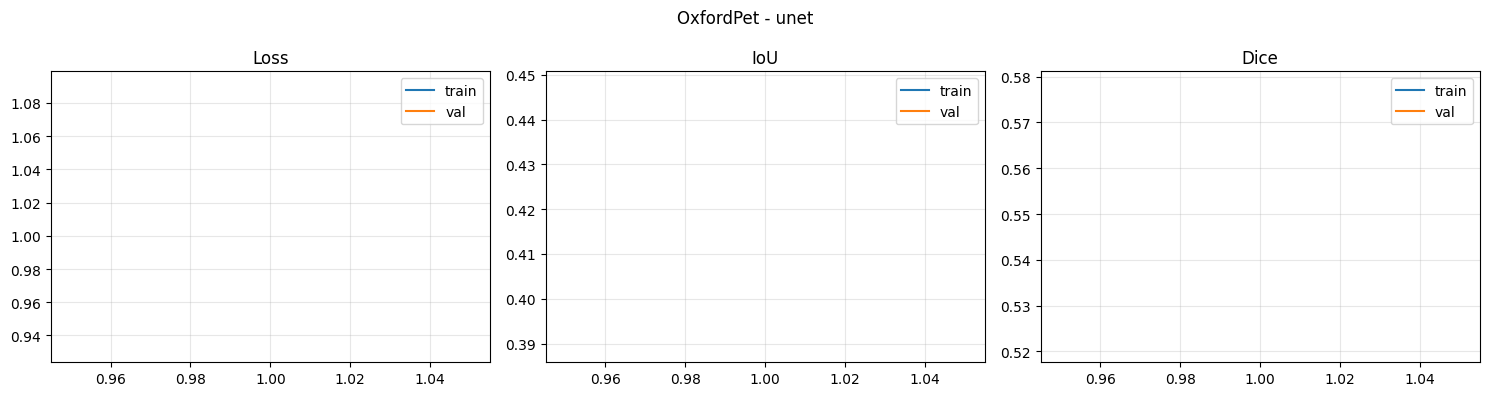

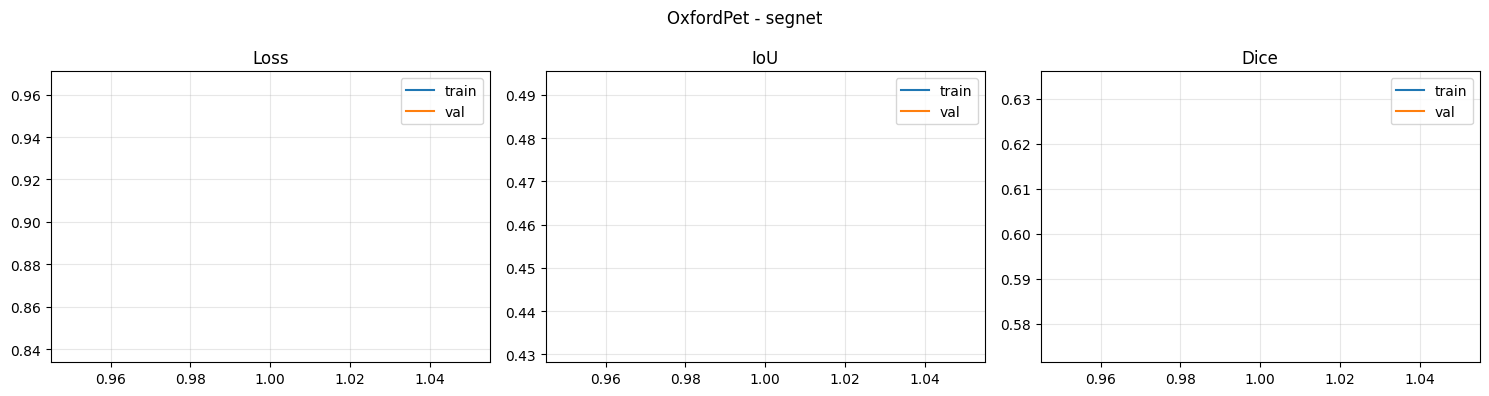

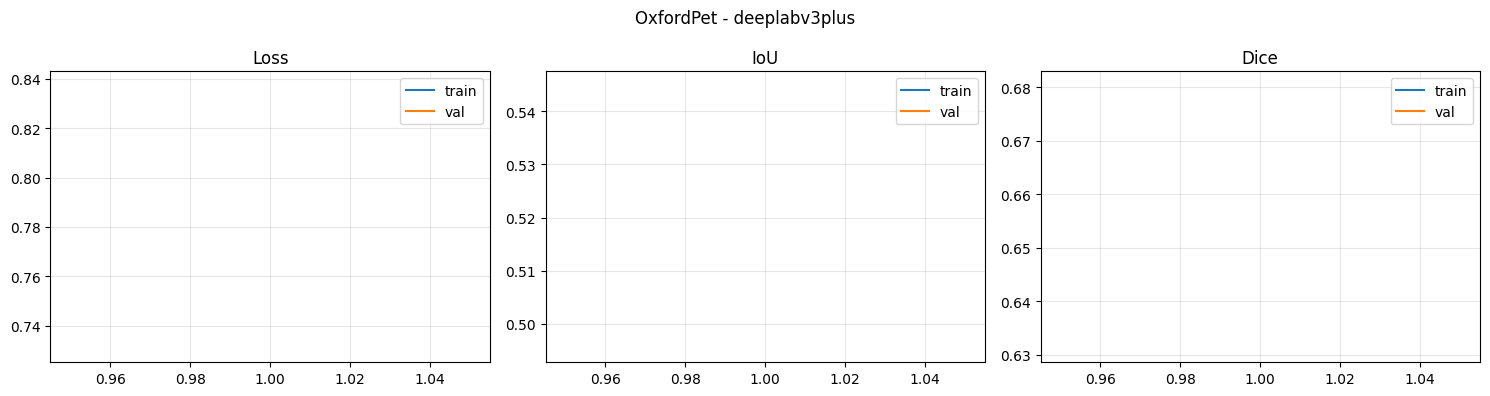

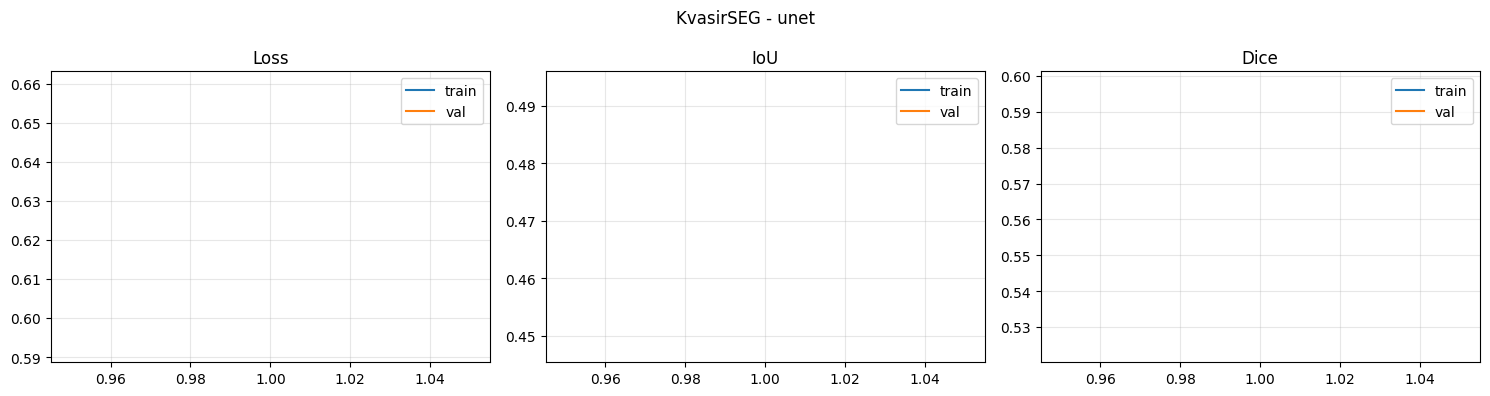

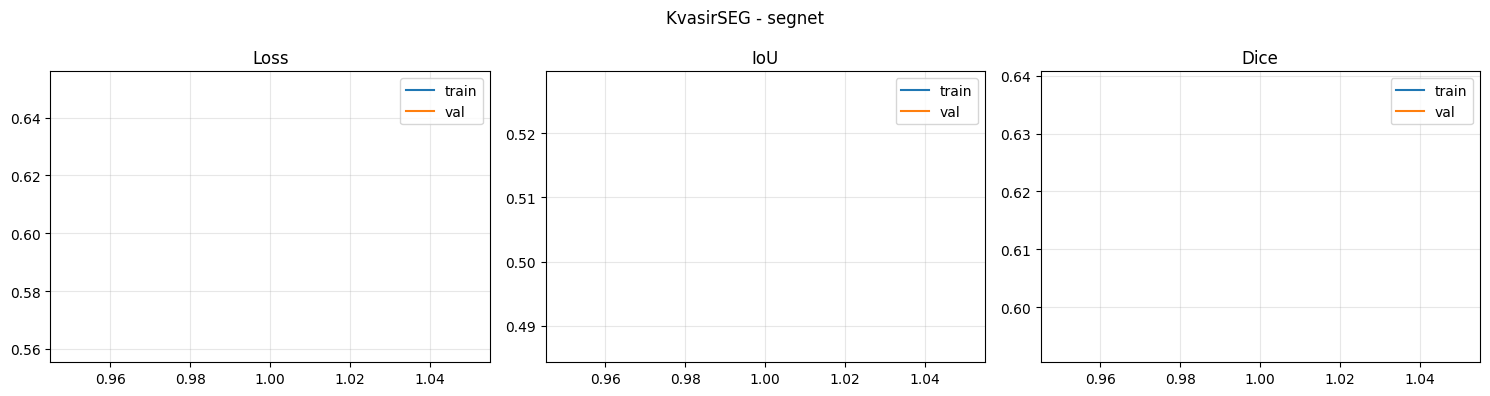

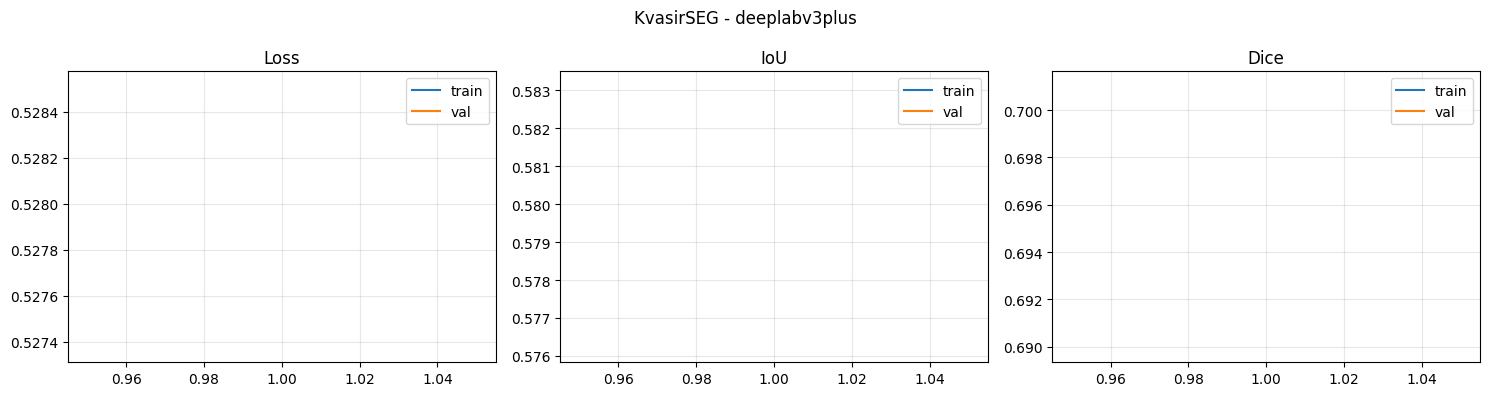

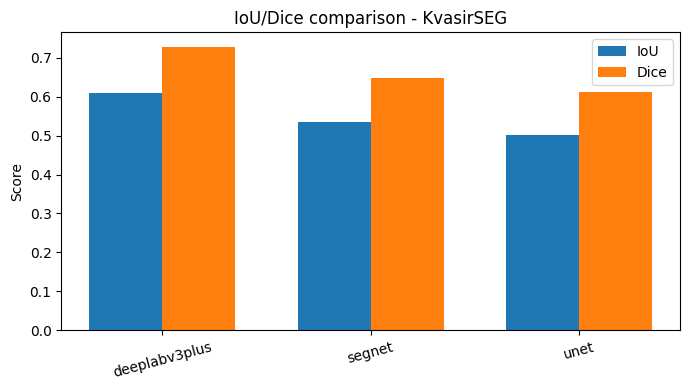

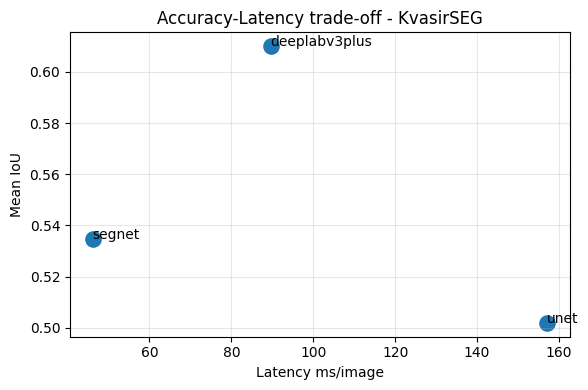

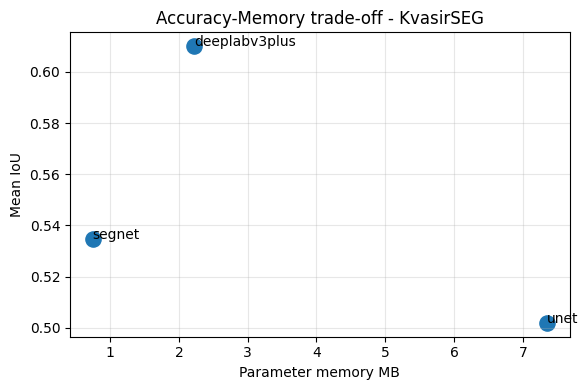

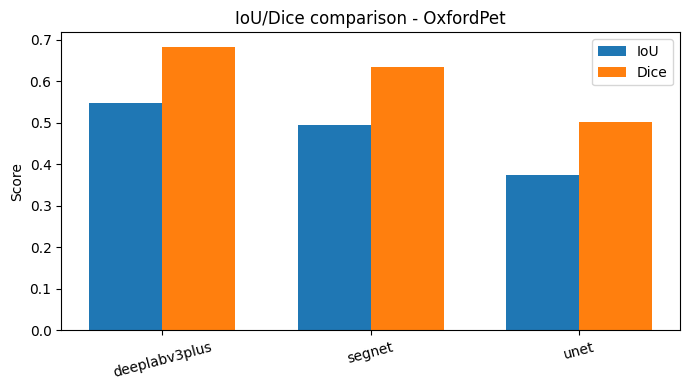

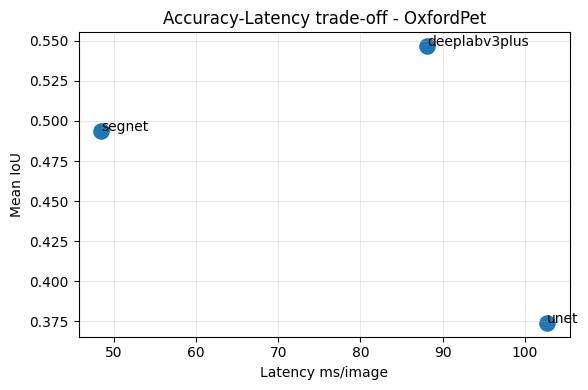

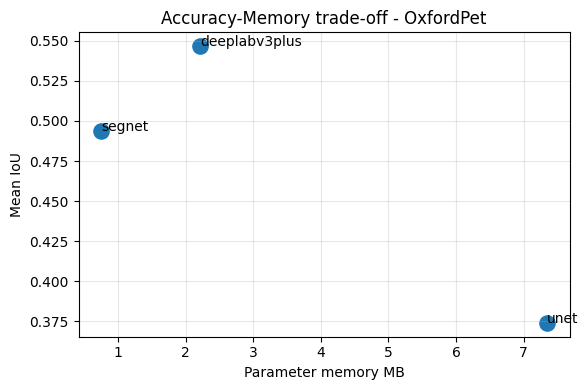

In [21]:
# ============================================================
# 16. Visualization: training curves and comparisons
# Bản an toàn: tự load results_df/summary_df nếu biến chưa tồn tại
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_results_if_needed(cfg):
    """
    Tự nạp results_df và summary_df nếu notebook chưa có biến này trong memory.
    Hỗ trợ:
    - /content/outputs_topic05/combined_all_results.csv
    - /content/outputs_topic05/combined_summary_mean_std.csv
    - /content/outputs_topic05/<Dataset>/all_results.csv
    - /content/outputs_topic05/<Dataset>/summary_mean_std.csv
    """

    output_root = Path(cfg.OUTPUT_ROOT)

    results_df = None
    summary_df = None

    combined_results_path = output_root / "combined_all_results.csv"
    combined_summary_path = output_root / "combined_summary_mean_std.csv"

    if combined_results_path.exists():
        results_df = pd.read_csv(combined_results_path)
        print("[LOAD] Loaded:", combined_results_path)

    if combined_summary_path.exists():
        summary_df = pd.read_csv(combined_summary_path)
        print("[LOAD] Loaded:", combined_summary_path)

    # Nếu chưa có combined file, đọc từng dataset folder
    if results_df is None:
        result_files = sorted(output_root.glob("*/all_results.csv"))
        dfs = []
        for f in result_files:
            try:
                dfs.append(pd.read_csv(f))
                print("[LOAD] Loaded:", f)
            except Exception as e:
                print("[WARNING] Không đọc được:", f, e)

        if len(dfs) > 0:
            results_df = pd.concat(dfs, ignore_index=True)

    if summary_df is None:
        summary_files = sorted(output_root.glob("*/summary_mean_std.csv"))
        dfs = []
        for f in summary_files:
            try:
                dfs.append(pd.read_csv(f))
                print("[LOAD] Loaded:", f)
            except Exception as e:
                print("[WARNING] Không đọc được:", f, e)

        if len(dfs) > 0:
            summary_df = pd.concat(dfs, ignore_index=True)

    return results_df, summary_df


# Nếu results_df/summary_df chưa tồn tại, tự load từ CSV
if "results_df" not in globals() or results_df is None:
    results_df, loaded_summary_df = load_results_if_needed(cfg)

    if "summary_df" not in globals() or summary_df is None:
        summary_df = loaded_summary_df

elif "summary_df" not in globals() or summary_df is None:
    _, summary_df = load_results_if_needed(cfg)


def plot_training_curves(results_df, max_runs=6):
    if results_df is None or len(results_df) == 0:
        print("[SKIP] Chưa có results_df. Hãy chạy run_experiments(cfg, device) trước.")
        return

    if "history_path" not in results_df.columns:
        print("[SKIP] results_df không có cột history_path.")
        return

    sample = results_df.head(max_runs)

    for _, row in sample.iterrows():
        hist_path = Path(row["history_path"])

        if not hist_path.exists():
            print("[WARNING] Không tìm thấy history:", hist_path)
            continue

        hist = pd.read_csv(hist_path)

        required_cols = [
            "epoch",
            "train_loss", "val_loss",
            "train_iou", "val_iou",
            "train_dice", "val_dice"
        ]

        missing = [c for c in required_cols if c not in hist.columns]
        if missing:
            print("[WARNING] History thiếu cột:", missing, "file:", hist_path)
            continue

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        axes[0].plot(hist["epoch"], hist["train_loss"], label="train")
        axes[0].plot(hist["epoch"], hist["val_loss"], label="val")
        axes[0].set_title("Loss")

        axes[1].plot(hist["epoch"], hist["train_iou"], label="train")
        axes[1].plot(hist["epoch"], hist["val_iou"], label="val")
        axes[1].set_title("IoU")

        axes[2].plot(hist["epoch"], hist["train_dice"], label="train")
        axes[2].plot(hist["epoch"], hist["val_dice"], label="val")
        axes[2].set_title("Dice")

        for ax in axes:
            ax.legend()
            ax.grid(True, alpha=0.3)

        dataset_name = row["dataset"] if "dataset" in row else "UnknownDataset"
        model_name = row["model"] if "model" in row else "UnknownModel"

        plt.suptitle(f"{dataset_name} - {model_name}")
        plt.tight_layout()
        plt.show()


def standardize_summary_columns(summary_df):
    """
    Chuẩn hóa tên cột vì một số version có thể dùng:
    mean_iou hoặc test_iou
    mean_dice hoặc test_dice
    mean_latency_ms hoặc latency_ms
    mean_param_memory_mb hoặc param_memory_mb
    """

    if summary_df is None:
        return None

    df = summary_df.copy()

    rename_map = {}

    if "mean_iou" not in df.columns and "test_iou" in df.columns:
        rename_map["test_iou"] = "mean_iou"

    if "mean_dice" not in df.columns and "test_dice" in df.columns:
        rename_map["test_dice"] = "mean_dice"

    if "mean_pixel_acc" not in df.columns and "test_pixel_acc" in df.columns:
        rename_map["test_pixel_acc"] = "mean_pixel_acc"

    if "mean_latency_ms" not in df.columns and "latency_ms" in df.columns:
        rename_map["latency_ms"] = "mean_latency_ms"

    if "mean_param_memory_mb" not in df.columns and "param_memory_mb" in df.columns:
        rename_map["param_memory_mb"] = "mean_param_memory_mb"

    df = df.rename(columns=rename_map)

    return df


def plot_model_comparison(summary_df):
    if summary_df is None or len(summary_df) == 0:
        print("[SKIP] Chưa có summary_df. Hãy chạy run_experiments hoặc tạo summary CSV trước.")
        return

    summary_df = standardize_summary_columns(summary_df)

    required = ["dataset", "model", "mean_iou", "mean_dice"]
    missing = [c for c in required if c not in summary_df.columns]

    if missing:
        print("[SKIP] summary_df thiếu cột:", missing)
        print("Các cột hiện có:", list(summary_df.columns))
        return

    for ds_name in summary_df["dataset"].unique():
        sub = summary_df[summary_df["dataset"] == ds_name]

        agg_cols = ["mean_iou", "mean_dice"]
        optional_cols = []

        if "mean_latency_ms" in sub.columns:
            optional_cols.append("mean_latency_ms")

        if "mean_param_memory_mb" in sub.columns:
            optional_cols.append("mean_param_memory_mb")

        base = (
            sub.groupby("model")[agg_cols + optional_cols]
            .mean(numeric_only=True)
            .reset_index()
        )

        x = np.arange(len(base))
        width = 0.35

        plt.figure(figsize=(7, 4))
        plt.bar(x - width / 2, base["mean_iou"], width, label="IoU")
        plt.bar(x + width / 2, base["mean_dice"], width, label="Dice")
        plt.xticks(x, base["model"], rotation=15)
        plt.ylabel("Score")
        plt.title(f"IoU/Dice comparison - {ds_name}")
        plt.legend()
        plt.tight_layout()
        plt.show()

        if "mean_latency_ms" in base.columns:
            plt.figure(figsize=(6, 4))
            plt.scatter(base["mean_latency_ms"], base["mean_iou"], s=120)

            for _, r in base.iterrows():
                plt.text(r["mean_latency_ms"], r["mean_iou"], r["model"])

            plt.xlabel("Latency ms/image")
            plt.ylabel("Mean IoU")
            plt.title(f"Accuracy-Latency trade-off - {ds_name}")
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print(f"[SKIP] {ds_name}: Không có cột mean_latency_ms.")

        if "mean_param_memory_mb" in base.columns:
            plt.figure(figsize=(6, 4))
            plt.scatter(base["mean_param_memory_mb"], base["mean_iou"], s=120)

            for _, r in base.iterrows():
                plt.text(r["mean_param_memory_mb"], r["mean_iou"], r["model"])

            plt.xlabel("Parameter memory MB")
            plt.ylabel("Mean IoU")
            plt.title(f"Accuracy-Memory trade-off - {ds_name}")
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print(f"[SKIP] {ds_name}: Không có cột mean_param_memory_mb.")


print("results_df:", None if results_df is None else results_df.shape)
print("summary_df:", None if summary_df is None else summary_df.shape)

display(results_df.head() if results_df is not None else "No results_df")
display(summary_df.head() if summary_df is not None else "No summary_df")

plot_training_curves(results_df)
plot_model_comparison(summary_df)

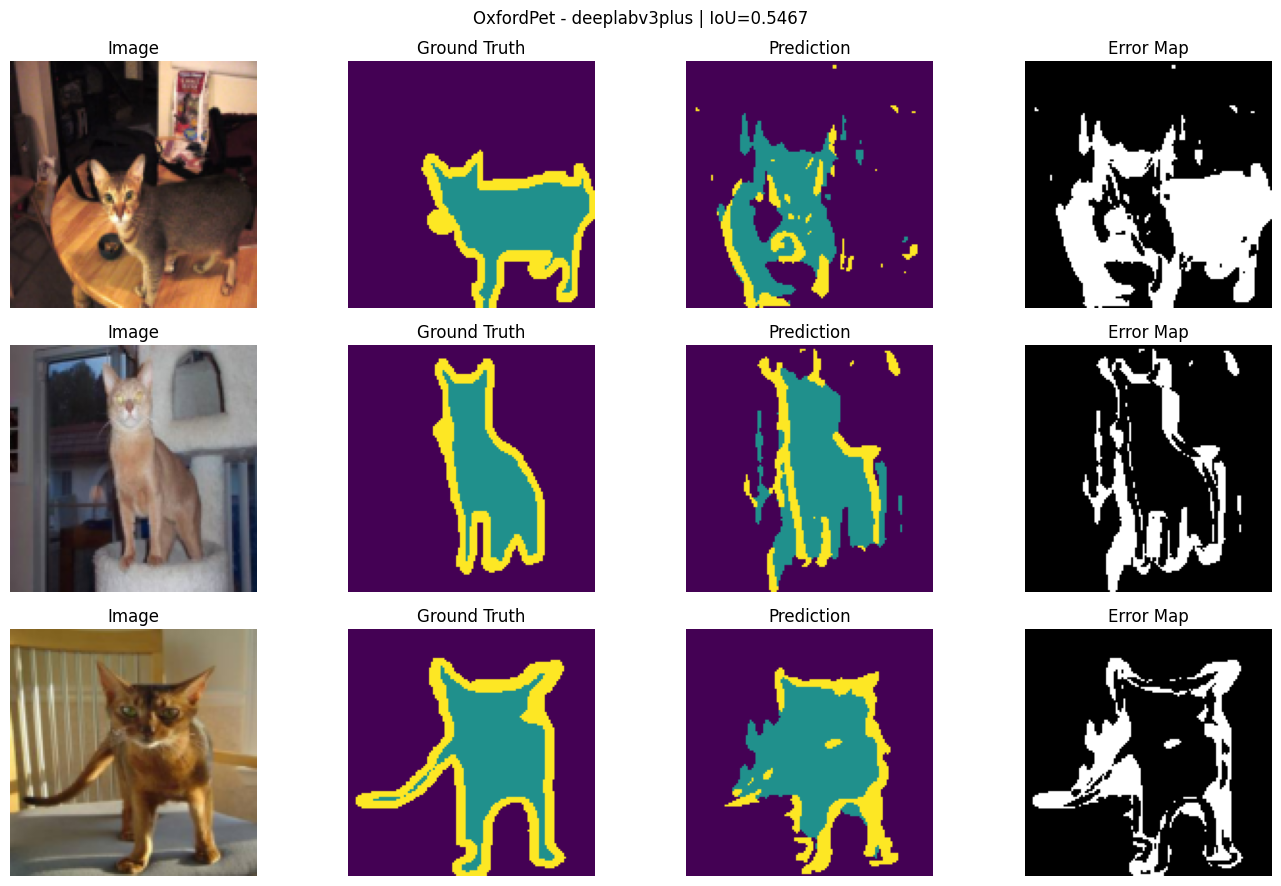

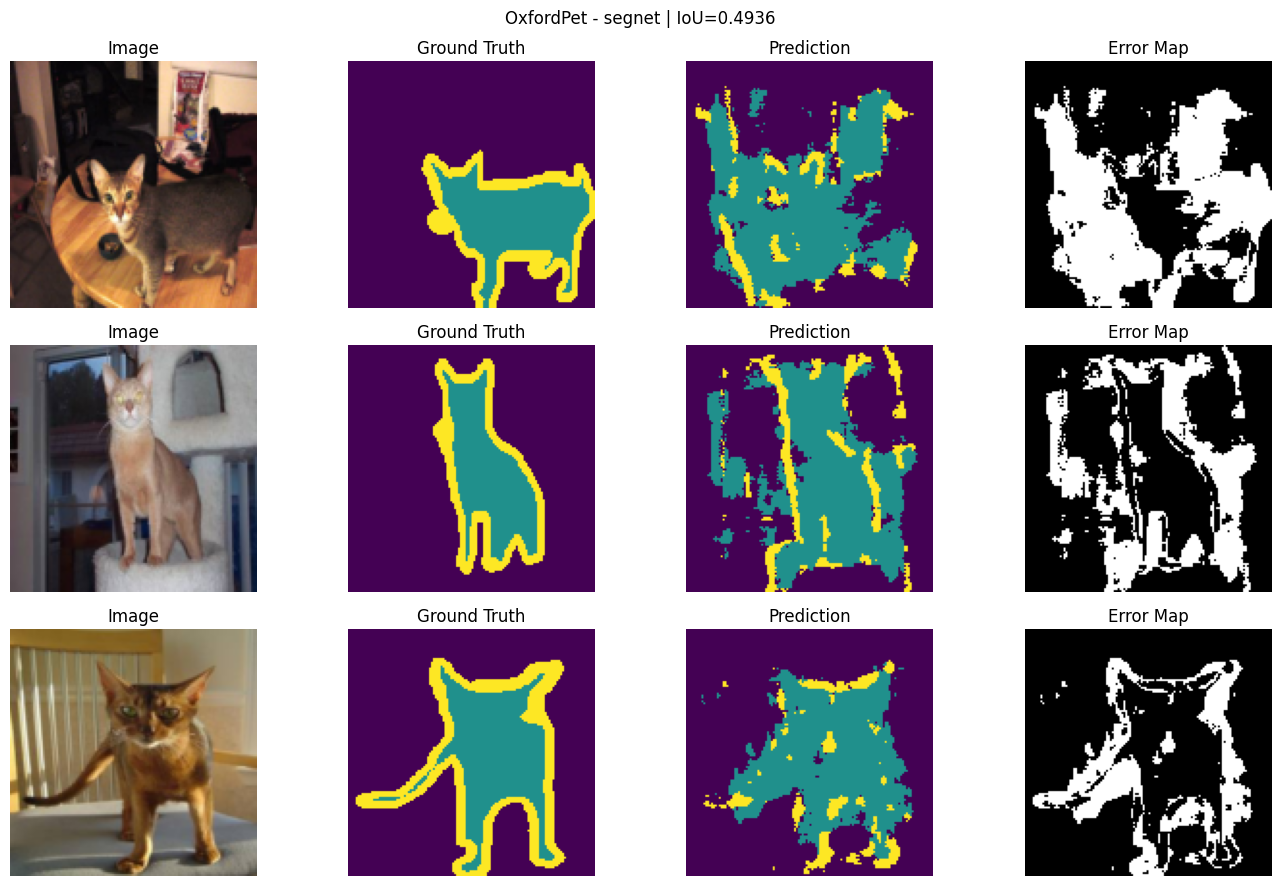

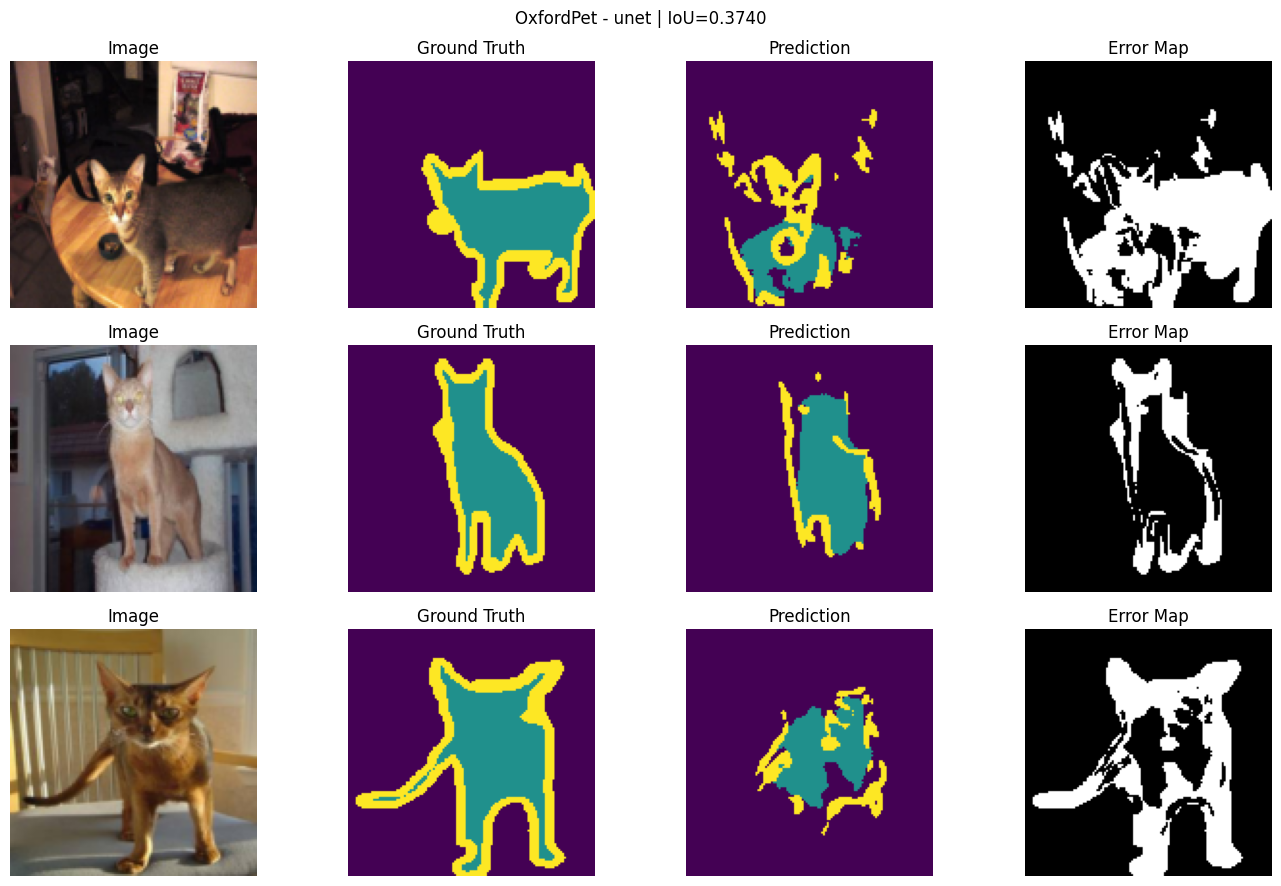

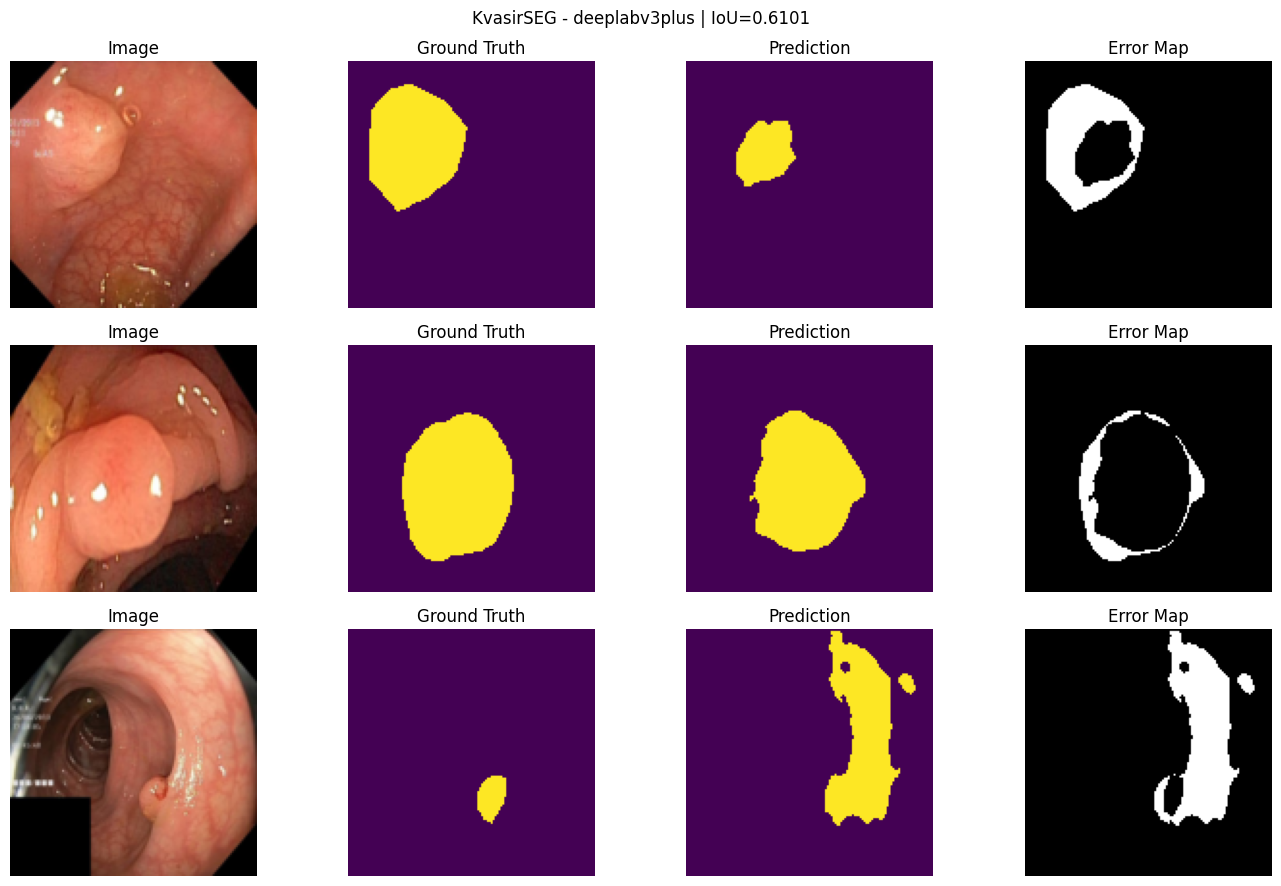

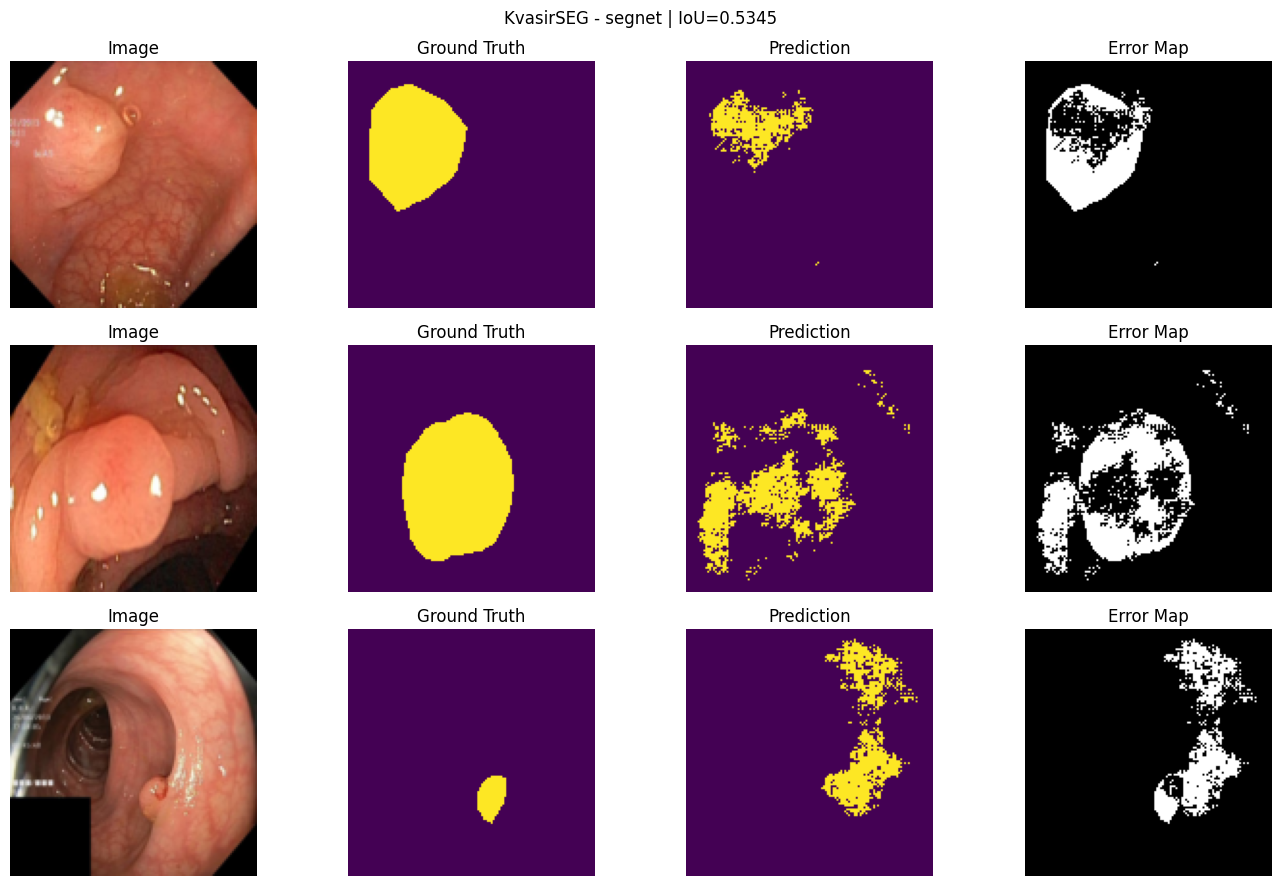

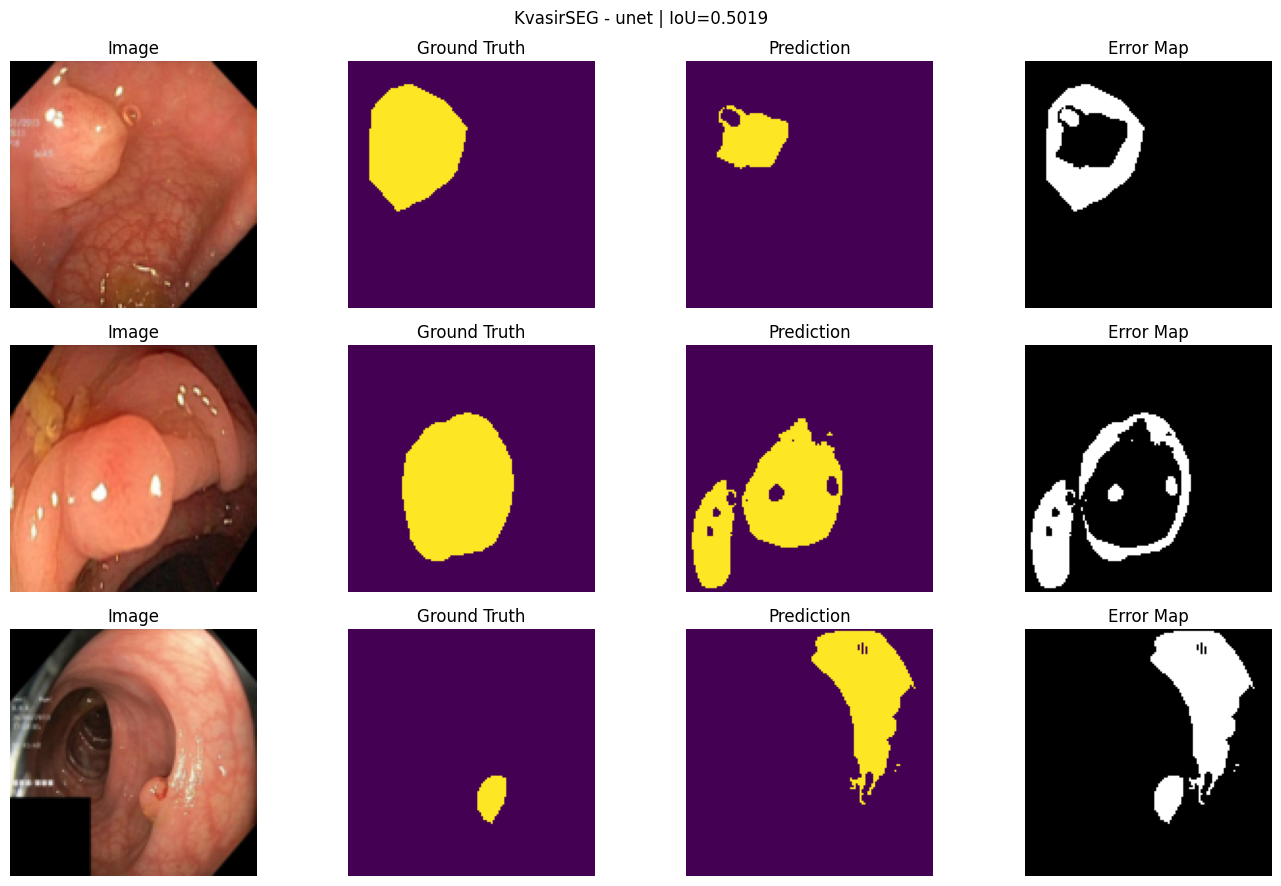

In [22]:
# ============================================================
# 17. Prediction masks and error maps
# ============================================================

@torch.no_grad()
def visualize_predictions_for_dataset(results_df, cfg, device, n=3):
    for ds_name in results_df["dataset"].unique():
        dataset_pack = build_dataset(ds_name, seed=42, cfg=cfg)
        test_ds = dataset_pack["test"]
        num_classes = dataset_pack["num_classes"]

        best_rows = (
            results_df[results_df["dataset"] == ds_name]
            .sort_values("test_iou", ascending=False)
            .groupby("model")
            .head(1)
        )

        for _, row in best_rows.iterrows():
            model = build_model(row["model"], num_classes).to(device)
            model.load_state_dict(torch.load(row["checkpoint_path"], map_location=device))
            model.eval()

            fig, axes = plt.subplots(n, 4, figsize=(14, 3*n))
            if n == 1:
                axes = np.expand_dims(axes, 0)

            for i in range(n):
                img, mask = test_ds[i]
                logits = model(img.unsqueeze(0).to(device))
                pred = torch.argmax(logits, dim=1).squeeze(0).cpu()
                err = (pred != mask).numpy().astype(np.uint8)

                axes[i,0].imshow(denormalize(img).permute(1,2,0))
                axes[i,0].set_title("Image")
                axes[i,0].axis("off")
                axes[i,1].imshow(mask, vmin=0, vmax=num_classes-1)
                axes[i,1].set_title("Ground Truth")
                axes[i,1].axis("off")
                axes[i,2].imshow(pred, vmin=0, vmax=num_classes-1)
                axes[i,2].set_title("Prediction")
                axes[i,2].axis("off")
                axes[i,3].imshow(err, cmap="gray")
                axes[i,3].set_title("Error Map")
                axes[i,3].axis("off")

            plt.suptitle(f"{ds_name} - {row['model']} | IoU={row['test_iou']:.4f}")
            plt.tight_layout()
            plt.show()

visualize_predictions_for_dataset(results_df, cfg, device, n=3)

Complexity OxfordPet-deeplabv3plus:   0%|          | 0/120 [00:00<?, ?it/s]

Complexity OxfordPet-segnet:   0%|          | 0/120 [00:00<?, ?it/s]

Complexity OxfordPet-unet:   0%|          | 0/120 [00:00<?, ?it/s]

Complexity KvasirSEG-deeplabv3plus:   0%|          | 0/120 [00:00<?, ?it/s]

Complexity KvasirSEG-segnet:   0%|          | 0/120 [00:00<?, ?it/s]

Complexity KvasirSEG-unet:   0%|          | 0/120 [00:00<?, ?it/s]

,dataset,model,group,iou,dice
0,KvasirSEG,deeplabv3plus,Dễ,0.606169,0.720252
1,KvasirSEG,deeplabv3plus,Khó,0.561088,0.640730
2,KvasirSEG,deeplabv3plus,Trung bình,0.651146,0.742749
3,KvasirSEG,segnet,Dễ,0.500102,0.624648
4,KvasirSEG,segnet,Khó,0.513448,0.587337
5,KvasirSEG,segnet,Trung bình,0.569355,0.669768
6,KvasirSEG,unet,Dễ,0.485447,0.599000
7,KvasirSEG,unet,Khó,0.481528,0.547568
8,KvasirSEG,unet,Trung bình,0.518131,0.605346
9,OxfordPet,deeplabv3plus,Dễ,0.463542,0.606766


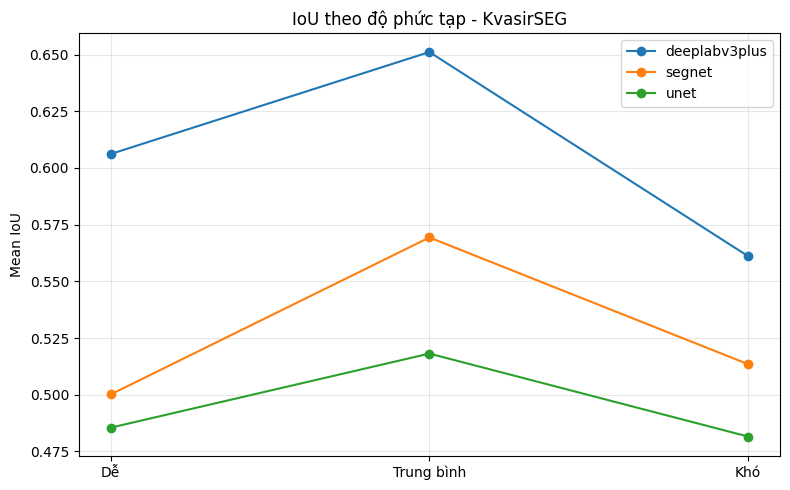

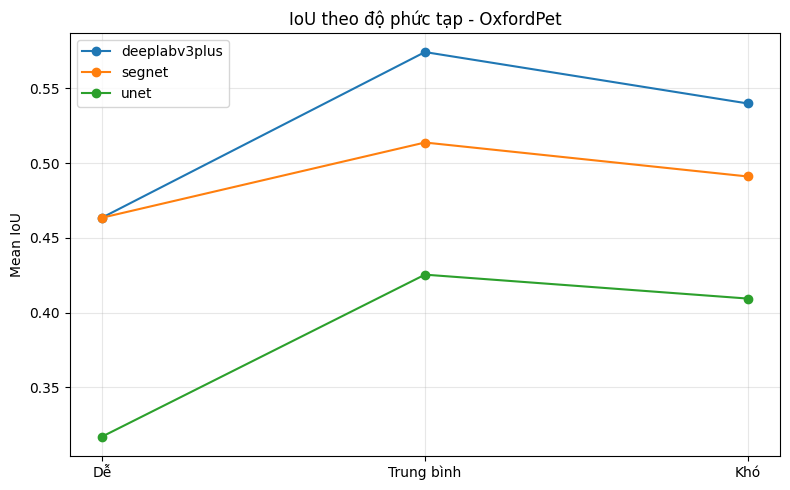

In [23]:
# ============================================================
# 18. Complexity-aware analysis
# ============================================================

def estimate_boundary_ratio(mask):
    arr = mask.numpy()
    h = np.abs(arr[:, 1:] - arr[:, :-1]).sum()
    v = np.abs(arr[1:, :] - arr[:-1, :]).sum()
    return (h + v) / arr.size

def compute_complexity(mask):
    fg = mask != 0
    fg_ratio = fg.sum().item() / mask.numel()
    boundary_ratio = estimate_boundary_ratio(mask)
    return boundary_ratio + 0.3 * (1 - fg_ratio)

@torch.no_grad()
def complexity_analysis(results_df, cfg, device, max_samples=120):
    rows = []
    for ds_name in results_df["dataset"].unique():
        dataset_pack = build_dataset(ds_name, seed=42, cfg=cfg)
        test_ds = dataset_pack["test"]
        num_classes = dataset_pack["num_classes"]

        complexities = []
        n = min(len(test_ds), max_samples)
        for idx in range(n):
            _, mask = test_ds[idx]
            complexities.append({"idx": idx, "complexity": compute_complexity(mask)})
        cdf = pd.DataFrame(complexities)
        cdf["group"] = pd.qcut(cdf["complexity"], q=3, labels=["Dễ", "Trung bình", "Khó"])

        best_rows = results_df[results_df["dataset"] == ds_name].sort_values("test_iou", ascending=False).groupby("model").head(1)

        for _, row in best_rows.iterrows():
            model = build_model(row["model"], num_classes).to(device)
            model.load_state_dict(torch.load(row["checkpoint_path"], map_location=device))
            model.eval()

            for _, cr in tqdm(cdf.iterrows(), total=len(cdf), desc=f"Complexity {ds_name}-{row['model']}"):
                img, mask = test_ds[int(cr["idx"])]
                logits = model(img.unsqueeze(0).to(device))
                metrics = calculate_metrics(logits, mask.unsqueeze(0).to(device), num_classes)
                rows.append({
                    "dataset": ds_name,
                    "model": row["model"],
                    "idx": int(cr["idx"]),
                    "complexity": cr["complexity"],
                    "group": cr["group"],
                    "iou": metrics["mean_iou"],
                    "dice": metrics["mean_dice"],
                })

    df = pd.DataFrame(rows)
    df.to_csv(Path(cfg.OUTPUT_ROOT) / "complexity_results.csv", index=False)

    summary = df.groupby(["dataset", "model", "group"])[["iou", "dice"]].mean().reset_index()
    display(summary)

    for ds_name in summary["dataset"].unique():
        sub = summary[summary["dataset"] == ds_name]
        plt.figure(figsize=(8,5))
        for model_name, grp in sub.groupby("model"):
            grp = grp.set_index("group").reindex(["Dễ", "Trung bình", "Khó"]).reset_index()
            plt.plot(grp["group"], grp["iou"], marker="o", label=model_name)
        plt.title(f"IoU theo độ phức tạp - {ds_name}")
        plt.ylabel("Mean IoU")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    return df

complexity_df = complexity_analysis(results_df, cfg, device)

# 6. Critical Discussion

## 6.1. Phân tích kết quả chính

Sau khi chạy notebook, sử dụng bảng `summary_mean_std.csv` của từng dataset và `combined_summary_mean_std.csv` để kết luận mô hình nào đạt Mean IoU và Dice cao nhất. Vì OxfordPet và KvasirSEG thuộc hai domain khác nhau, sự khác biệt hiệu năng giữa chúng phản ánh khả năng tổng quát hóa của mô hình.

## 6.2. Kiểm chứng giả thuyết

| Hypothesis | Evidence cần dùng | Kết luận |
|---|---|---|
| H1: U-Net tốt nhờ skip connections | So sánh IoU/Dice của U-Net với SegNet và DeepLabV3+ | Điền sau khi chạy full |
| H2: SegNet hiệu quả nhưng có thể kém ở biên | Latency, memory, error maps | Điền sau khi chạy full |
| H3: DeepLabV3+ tốt nhờ ngữ cảnh đa tỉ lệ | IoU/Dice, complexity-aware analysis | Điền sau khi chạy full |
| H4: Mô hình suy giảm khác nhau khi giảm dữ liệu | Data fraction experiments | Điền sau khi chạy full |
| H5: Không có mô hình tối ưu tuyệt đối | Accuracy–Latency–Memory plots | Điền sau khi chạy full |

## 6.3. Trade-off

Nếu một mô hình có IoU/Dice cao nhưng latency lớn, mô hình đó phù hợp với bài toán ưu tiên độ chính xác hơn tốc độ. Ngược lại, mô hình nhẹ hơn có thể phù hợp với triển khai trên thiết bị tài nguyên thấp.

## 6.4. Limitations

- DeepLabV3+ trong notebook là phiên bản compact, chưa phải full-scale.
- Chưa dùng pretrained backbone.
- Số epoch trong Colab Free có thể bị giới hạn.
- Kết quả latency phụ thuộc phần cứng.
- Nếu chỉ chạy QUICK_RUN, kết quả chỉ mang tính kiểm tra pipeline, không dùng để kết luận cuối cùng.

## 6.5. Future Work

- Thêm Cityscapes hoặc CamVid để có domain urban scene.
- Dùng pretrained encoder như ResNet34, MobileNetV2.
- Thử Boundary Loss, Focal Loss, Tversky Loss.
- Tối ưu inference bằng pruning, quantization hoặc ONNX.

In [24]:
# ============================================================
# 19. Export outputs
# ============================================================

import shutil
zip_name = "/content/topic05_outputs.zip"
shutil.make_archive("/content/topic05_outputs", "zip", cfg.OUTPUT_ROOT)
print("Exported:", zip_name)

Exported: /content/topic05_outputs.zip


# 7. Final Submission Checklist

- [ ] `QUICK_RUN=False` nếu chạy kết quả chính thức.
- [ ] Runtime dùng T4 GPU khi chạy full.
- [ ] Có output cho OxfordPet.
- [ ] Có output cho KvasirSEG.
- [ ] Mỗi dataset có folder output riêng.
- [ ] Có `combined_summary_mean_std.csv`.
- [ ] Có prediction masks và error maps.
- [ ] Có complexity-aware analysis.
- [ ] Critical discussion được điền bằng kết quả thật.
- [ ] Nén `outputs_topic05` thành `topic05_outputs.zip`.